# Chapter 22

# Working with non-Normal distributions and the generalized linear model

### Steve Elston

**Instructions:** Complete the exercises in this notebook. Some exercises require coding. The answers to the exercise questions should be short and succinct. **Most question answers require only one to three sentences**. Use of overly long answers will result in loss of credit. Please thin about the theory behind the question and apply the reasoning required to create an answer. AI use must conform to the course policy as written in the Syllabus. Do not use an LLM or other AI to create your answers to the conceptual questions. 

**Attribution:** Some of the code in this notebook was modified from code originally developed using Copilot and Gemini, LLMs. 

## Introduction

Up to now, we have only worked with **numeric variables**. However, **categorical variables** are extremely common. In fact, most real-world data science problems involve one or more categorical variables. Indeed, some types of analysis involve only categorical variables. For examine, in natural language processing, all variables are categorical in the form of words or phrases. 

Machine learning models can have categorical variables as features. But, most models require numeric predictor variables. The question is, how can we transform categorical variables into numeric variables?  

In this notebook you will be introduced to working with categorical variables as features in regression models. The methods explored apply to most any machine learning model.  

## Preparing the Data Set

In this section we will prepare the data set we will use in this notebook. As a first step, execute the code in the cell below to import the required packages.

In [1]:
import pandas as pd
import numpy as np
import numpy.random as nr
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf  
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.graphics.regressionplots import influence_plot, plot_regress_exog
from statsmodels.graphics.factorplots import interaction_plot
import itertools
import scipy.stats as ss
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize, StandardScaler
from patsy import dmatrices
from sklearn import metrics
import contextlib
import math
import io
import sys

%matplotlib inline
sns.set(style='ticks', palette='Set2')

## Some checks
import scipy
import numba
import sklearn
print("Environment version: " + sys.version)
print("Numpy version: " + np.__version__)
print("Pandas version: " + pd.__version__)
print("StatsModels version: " + statsmodels.__version__)
print("Seaborn version: " + sns.__version__)
print('scipy version: ' + scipy.__version__)
print('Numba version: ' + numba.__version__)
print('Pandas version: ' + pd.__version__)
print('Scikit-Learn version: ' + sklearn.__version__)
print('Scipy version: ' + scipy.__version__)

Environment version: 3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]
Numpy version: 1.26.4
Pandas version: 3.0.5
StatsModels version: 0.14.6
Seaborn version: 0.13.2
scipy version: 1.17.1
Numba version: 0.65.1
Pandas version: 3.0.5
Scikit-Learn version: 1.9.0
Scipy version: 1.17.1


Execute the cell below to perform load the dataset into a data frame and examine the data types of the columns. 

In [2]:
auto_data = pd.read_csv('../data/AutoPricesClean.csv')
auto_data.dtypes                      

Unnamed: 0             int64
symboling              int64
normalized_losses        str
make                     str
fuel_type                str
aspiration               str
num_of_doors             str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_of_cylinders         str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower             int64
peak_rpm               int64
city_mpg               int64
highway_mpg            int64
price                  int64
dtype: object

There are a number of numeric variables and categorical variables, of type `object`.

Next, execute the code in the cell below to do the following:   

- Remove the first 3 columns of the data frame. 
- Standardize the numeric columns of the data frame, except for the last 3 we can use as labels.
- Convert the string columns to Pandas object type so that they work for categorical variables.
- Convert integer columns to float.    
- Examine the head of the data frame.   

In [3]:
## Get a list of columns that are not of type object   
auto_data.drop(auto_data.columns[:3], axis=1, inplace=True)
numeric_columns = [col for col_type,col in zip(auto_data.iloc[:,:-3].dtypes,auto_data.iloc[:,:-3].columns) if col_type in ['int64','float64']]

temp = auto_data[numeric_columns].apply(pd.to_numeric, downcast=None)
auto_data[numeric_columns] = StandardScaler().fit_transform(temp)

string_cols = auto_data.select_dtypes(include=["string"]).columns
auto_data[string_cols] = auto_data[string_cols].astype("object")

int_cols = auto_data.select_dtypes(include=["int64"]).columns
auto_data[int_cols] = auto_data[int_cols].astype("float")

auto_data.head()

,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,-1.683439,-0.438504,-0.839749,...,0.049883,mpfi,0.518555,-1.820278,-0.294933,0.204599,-0.213003,21.0,27.0,13495.0
1,alfa-romero,gas,std,two,convertible,rwd,front,-1.683439,-0.438504,-0.839749,...,0.049883,mpfi,0.518555,-1.820278,-0.294933,0.204599,-0.213003,21.0,27.0,16500.0
2,alfa-romero,gas,std,two,hatchback,rwd,front,-0.718803,-0.245646,-0.181548,...,0.582216,mpfi,-2.394771,0.701202,-0.294933,1.342993,-0.213003,19.0,26.0,16500.0
3,audi,gas,std,four,sedan,fwd,front,0.147735,0.188283,0.147553,...,-0.458253,mpfi,-0.514016,0.477780,-0.048122,-0.033670,0.857502,24.0,30.0,13950.0
4,audi,gas,std,four,sedan,4wd,front,0.082336,0.188283,0.241582,...,0.195065,mpfi,-0.514016,0.477780,-0.541744,0.310496,0.857502,18.0,22.0,17450.0


Our goal with these data is to model the city MPG. Therefore, we will start with displaying a graph of the city MPG vs. curb weight for the two fuel types. Execute the code in the cell below and examine the  

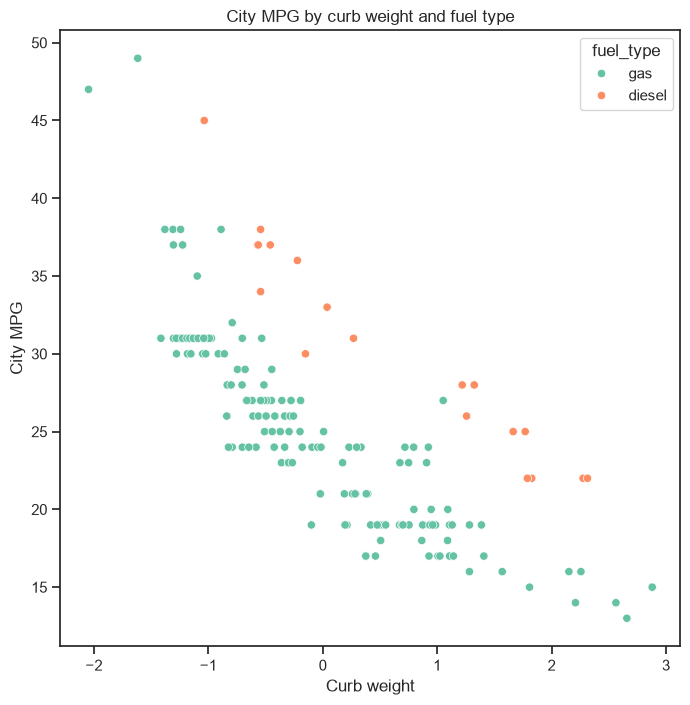

In [4]:
def plot_auto(x='curb_weight', y='city_mpg', hue='fuel_type', 
              title = 'City MPG by curb weight and fuel type', 
              xlabel='Curb weight', ylabel='City MPG',
              data=auto_data):
    fig,ax = plt.subplots(figsize=(8,8))
    sns.scatterplot(x=x, y=y, hue=hue, data=data);
    ax.set_title(title);
    ax.set_xlabel(xlabel);
    ax.set_ylabel(ylabel);
    plt.show()
    return ax
    
_=plot_auto()    

## Categorical Variables and the Model Matrix

Most machine learning models can only work with numeric variables. Therefore, we need to encode the categorical variables into one or more numeric variables. The common approach is to convert the categorical variable to a set of binary **dummy variables** or **indicator variables**. We call this process **one-hot encoding** since only one of the dummy variables will be encoded as a 1 for each category or level of the variable. 

We will work with the Python [patsy](https://patsy.readthedocs.io/en/latest/quickstart.html) package which creates **design matrices** from Pandas data frames. Patsy creates the design matrices using the, by now familiar, R-style modeling [formulas](https://patsy.readthedocs.io/en/latest/formulas.html). These design matrices can be used directly in statsmodels or scikit-learn models. 

> **Note:** In this lesson we will use the term design matrices. However, you often see the term **model matrices**. Don't be confused! These terms mean the same thing.

### Design matrix with an intercept term

To start our exploration of how model matrices are constructed we will start with an example using only numeric variables. We will use the [dmatrices](https://patsy.readthedocs.io/en/latest/API-reference.html) function from the Patsy package, which returns both the feature and label matrices. A model formula is used to define the model created by the matrices returned by dmatricies. Execute the code in the cell below to construct the label and design matrices for the model formula shown and examine the results. 

In [5]:
print('Unique values of drive wheels = ' + str(auto_data.drive_wheels.unique()))
print('Unique values of body style = ' + str(auto_data.body_style.unique()))
formula = 'city_mpg ~ C(body_style)'
Y, X = dmatrices(formula, data=auto_data)
print('\nHead of label matrix \n{}\n'.format(Y[:5]))
print('Head design matrix \n{}'.format(X[:10]))

Unique values of drive wheels = ['rwd' 'fwd' '4wd']
Unique values of body style = ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

Head of label matrix 
[[21.]
 [21.]
 [19.]
 [24.]
 [18.]]

Head design matrix 
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [1. 0. 0. 1. 0.]
 [1. 0. 0. 1. 0.]
 [1. 0. 0. 1. 0.]
 [1. 0. 0. 1. 0.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 1. 0.]
 [1. 0. 0. 1. 0.]]


The label array, $Y$, looks much as you might expect. A one dimensional array of label values.  

The columns of the feature matrix might surprise you.  The first column is all 1's. This is the feature column for the **intercept term**. There are 4 containing dummy variables encoding the body style.

But notice that first two rows have only 0s for the dummy variables? How can this be? It turns out the intercept term is the mean of the first category of `body_style`. The other columns represent **contrasts** between the intercept and the **effect size** of the other categories. 

###  Design matrices without an intercept term 

We may not always want an intercept term. Patsy allows us to build a design matrix without an intercept term by including -1 in the formula. Execute the code in the cell below which does just this.     

In [6]:
Y, X = dmatrices('city_mpg ~ -1 + C(body_style)', data=auto_data)
print('Head of label matrix \n{}\n'.format(Y[:10]))
print('Design matrix \n{}'.format(X[:10]))

Head of label matrix 
[[21.]
 [21.]
 [19.]
 [24.]
 [18.]
 [19.]
 [19.]
 [19.]
 [17.]
 [23.]]

Design matrix 
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]]


The result is an array with 5 dummy variables, representing the 5 levels of the categorical variable. There is no longer an intercept column. 

Each of the levels of the categorical variable are now represented by a dummy variable. These dummy variables now represent the means for each level, not the contrasts. The feature matrix no longer has a column of 1s. By not using contrasts, the need for an intercept term is eliminated. 

We can test that this design matrix is **orthogonal**. By orthogonal, we mean that each dummy variable is not linearly dependent on any other. An orthogonal design matrix has several advantages. First, the inverse of the covariance matrix is guaranteed to exist. Second, we can directly interpret the model coefficients in terms of the response to the values of the predictor variables.  

The code in the cell below demonstrates the orthogonality of the design matrix by taking the dot products of every pairwise combination. Recall that the dot product between orthogonal vectors is zero. Execute this code and examine the results. 

In [7]:
from itertools import combinations
for i,j in combinations(range(5), 2):
    print('For columns {0:1d} and {1:1d} the dot product = {2:3.2f}'.format(i,j,np.dot(X[:,i],X[:,j])))

For columns 0 and 1 the dot product = 0.00
For columns 0 and 2 the dot product = 0.00
For columns 0 and 3 the dot product = 0.00
For columns 0 and 4 the dot product = 0.00
For columns 1 and 2 the dot product = 0.00
For columns 1 and 3 the dot product = 0.00
For columns 1 and 4 the dot product = 0.00
For columns 2 and 3 the dot product = 0.00
For columns 2 and 4 the dot product = 0.00
For columns 3 and 4 the dot product = 0.00


## Design Matrices with Mixed Type Variables

It is also possible to create design matrices with both categorical variables and continuous numeric variables. The numeric variables must be normalized to be on the same scale as the dummy variables.      

The resulting design matrix, uses the means of the levels of a categorical variable as the model coefficients. In other words, these coefficients represent the value for each level rather than contrasts with an intercept.    

Execute the code in the cell below to create a design matrix with no intercept term with categorical variable `body_style` and normalized continuous variables `engine_size` and `curb_weight`, with no intercept. 

In [8]:
Y, X = dmatrices('city_mpg ~ -1 + C(body_style) + curb_weight + engine_size', data=auto_data)
print('Head of label matrix \n{}\n'.format(Y[:5]))
print('Design matrix \n{}'.format(np.round(X[:5], 4)))

Head of label matrix 
[[21.]
 [21.]
 [19.]
 [24.]
 [18.]]

Design matrix 
[[ 1.      0.      0.      0.      0.     -0.021   0.0499]
 [ 1.      0.      0.      0.      0.     -0.021   0.0499]
 [ 0.      0.      1.      0.      0.      0.5044  0.5822]
 [ 0.      0.      0.      1.      0.     -0.4242 -0.4583]
 [ 0.      0.      0.      1.      0.      0.5063  0.1951]]


There are 7 columns in this design matrix. The first 5 columns are the dummy variables for the categorical variables for the contrasts of the levels. The last two columns are the values of the normalized numeric columns.   

One question you could ask, is if the columns of the design matrix are orthogonal? Execute the code in the cell below to find out.     

In [9]:
for i,j in combinations(range(7), 2):
    print('For columns {0:1d} and {1:1d} the dot product = {2:3.2f}'.format(i,j,np.dot(X[:,i],X[:,j])))

For columns 0 and 1 the dot product = 0.00
For columns 0 and 2 the dot product = 0.00
For columns 0 and 3 the dot product = 0.00
For columns 0 and 4 the dot product = 0.00
For columns 0 and 5 the dot product = 2.78
For columns 0 and 6 the dot product = 4.24
For columns 1 and 2 the dot product = 0.00
For columns 1 and 3 the dot product = 0.00
For columns 1 and 4 the dot product = 0.00
For columns 1 and 5 the dot product = 3.85
For columns 1 and 6 the dot product = 9.35
For columns 2 and 3 the dot product = 0.00
For columns 2 and 4 the dot product = 0.00
For columns 2 and 5 the dot product = -29.36
For columns 2 and 6 the dot product = -19.55
For columns 3 and 4 the dot product = 0.00
For columns 3 and 5 the dot product = 12.01
For columns 3 and 6 the dot product = 8.54
For columns 4 and 5 the dot product = 10.72
For columns 4 and 6 the dot product = -2.58
For columns 5 and 6 the dot product = 167.23


Examine the results above. The dummy variables are orthogonal as they should be. However, the dummy variables are not orthogonal to the numeric variables. Further, the numeric columns are not orthogonal.          

> **Exercise 22-1:** To better understand how the encoding of the dummy variables as contrasts works do the following:       
> 1. Define and fit an ols model of `city_mpg` by `fuel_type + curb_weight + curb_weight^2` using the [statsmodels.formula.api.ols](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html) function. Make sure you wrap the categorical variable in the `C()` operator and use the `I()` operator for the power term.     
> 2. Print the summary of this model.    

In [10]:
## Put your code below



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               city_mpg   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     365.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           6.77e-79
Time:                        08:49:48   Log-Likelihood:                -452.08
No. Observations:                 195   AIC:                             912.2
Df Residuals:                     191   BIC:                             925.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              32.3655      0.594     54.484      0.000      31.194      33.537
C(fuel_type)[T.gas]    -9.2490      0.602    -15.373      0.000     -10.436      -8.062
curb_weight            -6.4280      0.207    -31.095      0.000      -6.836      -6.020
I(curb_weight ** 2)     1.3092      0.148      8.868      0.000       1.018       1.600
==============================================================================
Omnibus:                       51.333   Durbin-Watson:                   1.569
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              134.425
Skew:                           1.123   Prob(JB):                     6.46e-30
Kurtosis:                       6.392   Cond. No.                         9.19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> Answer the following questions:   
> 1. Notice that there is 1 dummy variable representing 2 possible values. Which category of this variable is represented by the intercept term?     
> 2. Which of the parameters do you consider to be significant and why? 
> 3. What does the contrast variable tell you about the average city MPG for these categories and why?    
> 4. Based on adjusted $R^2$ and F-statistic does this model explain any of the variance of the city MPG?  

> **Answers:**      
> 1.      
> 2.    
> 3.      
> 4.     

>**Exercise 22-2:** You will now investigate how dropping the intercept term changes the behavior and interpretation of the model coefficients by doing the following:
     
> 1. Define and fit an ols model of `city_mpg` by `fuel_type + curb_weight + curb_weight^2` with no intercept using the `ols` function from `statsmodels.formula.api`. Name your model `city_mpg_ols_no_intercept`. Make sure you wrap the categorical variable in the `C()` operator.   
> 2. Print the summary of this model.    

In [11]:
## Put your code below





<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               city_mpg   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     365.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           6.77e-79
Time:                        08:49:48   Log-Likelihood:                -452.08
No. Observations:                 195   AIC:                             912.2
Df Residuals:                     191   BIC:                             925.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
C(fuel_type)[diesel]    32.3655      0.594     54.484      0.000      31.194      33.537
C(fuel_type)[gas]       23.1165      0.237     97.393      0.000      22.648      23.585
curb_weight             -6.4280      0.207    -31.095      0.000      -6.836      -6.020
I(curb_weight ** 2)      1.3092      0.148      8.868      0.000       1.018       1.600
==============================================================================
Omnibus:                       51.333   Durbin-Watson:                   1.569
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              134.425
Skew:                           1.123   Prob(JB):                     6.46e-30
Kurtosis:                       6.392   Cond. No.                         6.17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> 3. Next, run the code in the cell below to display diagnostic plots for the model.  

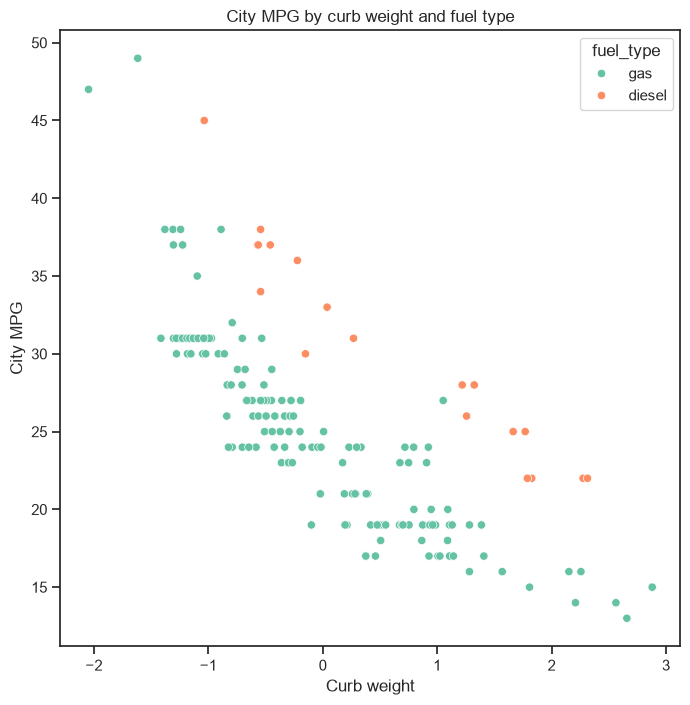

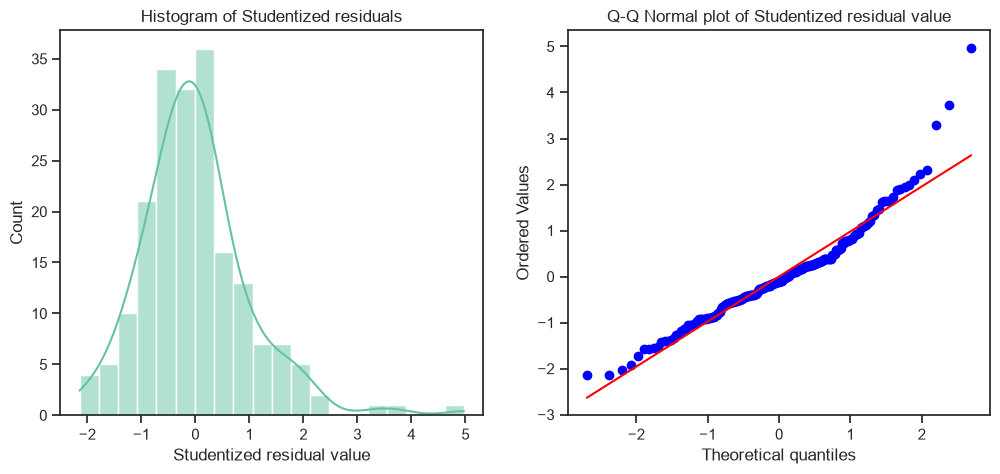

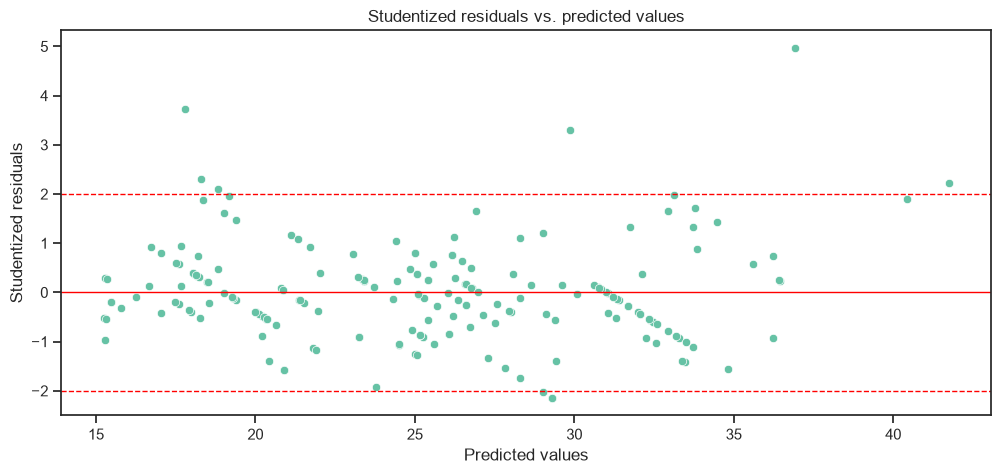

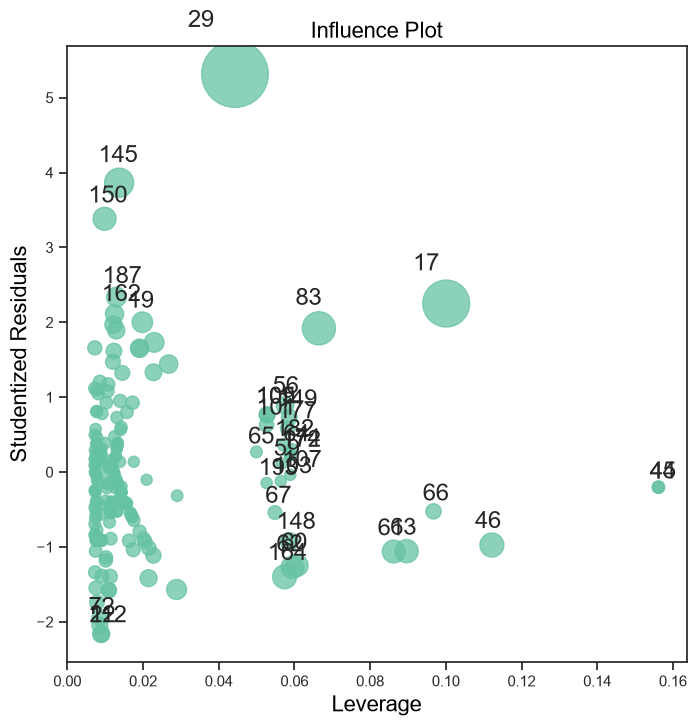

In [12]:
def plot_resid_dist(resids,
                   xlab='Studentized residual value',
                   title = 'Histogram of Studentized residuals'):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    ## Plot a histogram
    sns.histplot(resids, bins=20, kde=True, ax=ax[0])
    ax[0].set_title(title)
    ax[0].set_xlabel(xlab)
    ## Plot the Q-Q Normal plot
    ss.probplot(resids, plot = ax[1])
    ax[1].set_title('Q-Q Normal plot of ' + xlab)
    plt.show()
    
def residual_plot(df, 
                  predicted='predicted', 
                  resids='resids', 
                 xlab='Predicted values',
                 ylab='Studentized residuals',
                 title='Studentized residuals vs. predicted values'):
    fig,ax = plt.subplots(figsize=(12,5))
    RMSE = np.std(df.loc[:,resids])
    sns.scatterplot(x=predicted, y=resids, data=df, ax=ax)
    ax.axhline(0.0, color='red', linewidth=1.0)
    ax.axhline(2.0*RMSE, color='red', linestyle='dashed', linewidth=1.0)
    ax.axhline(-2.0*RMSE, color='red', linestyle='dashed', linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    plt.show()    

auto_data.loc[:,'predicted'] = city_mpg_ols_no_intercept.predict(auto_data)
influence = city_mpg_ols_no_intercept.get_influence()
auto_data['resids'] = influence.resid_studentized_internal

ax = plot_auto()
sns.lineplot(x='curb_weight', y='predicted', hue='fuel_type', data=auto_data, ax=ax)

plot_resid_dist(auto_data.resids)
residual_plot(auto_data) 

fig,ax = plt.subplots(figsize=(8,8))
_=influence_plot(city_mpg_ols_no_intercept, ax=ax)

> 4. Notice there are some high leverage points associated with large residual values. Create and execute code to print the `make`, `city_mpg`, `fuel_type`, `curb_weight`, and `resids` columns for the 5 observations with the highest leverage in descending order of influence. The highest influence observations have the largest marker size.    

In [13]:
## Your code goes here




,make,city_mpg,fuel_type,curb_weight,resids
17,chevrolet,47.0,gas,-2.046359,2.226940
46,jaguar,13.0,gas,2.657782,-0.974468
66,mercedes-benz,14.0,gas,2.562247,-0.526035
45,jaguar,15.0,gas,2.879424,-0.202765
44,jaguar,15.0,gas,2.879424,-0.202765


> Examine the results and answer these questions:    
> 1. Notice that 2 of the model coefficients represent the mean for each category of fuel type and all coefficients are significant. How can you interpret the two values of the fuel coefficients?   
> 2. Compare the intercept term for the first model to the diesel fuel coefficient in the second model. Are these values and same and why? 
> 3. Have the slope coefficients for curb weight and curb weight squared changed between the models with and without an intercept term?   
> 4. How can you best describe the distribution of the residuals for this model?    
> 5. Examine the residual plot, noting that the pattern arising from the integer coded values of city MPG, but which can generally be ignored in evaluation of the residuals.  Are the residuals homoscedastic or heteroscedastic, and why?    
> 6. What statement can you make in terms of explaining the high leverage points?    

> **Answer:**      
> 1.    
> 2.      
> 3.    
> 4.    
> 5.    
> 6.    

At this point it is worth asking what the distributions of the parameters look like. To find out we can use a parametric bootstrap to get find an approximate distribution of the model parameters. To do so, execute the code in the cell below.     

Parameter = diesel fuel
Mean = 32.330045959178264
Upper confidence interval = 33.300044894503294
Lower confidence interval = 31.224042550546656


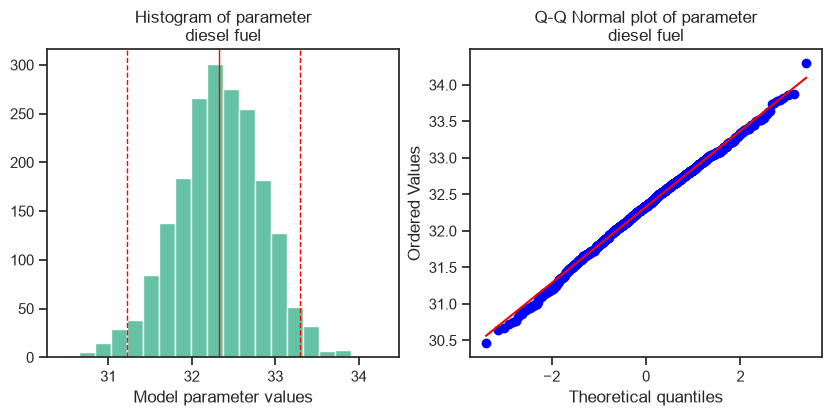

Parameter = gas fuel
Mean = 23.098907818621356
Upper confidence interval = 23.532614789420663
Lower confidence interval = 22.677140269049104


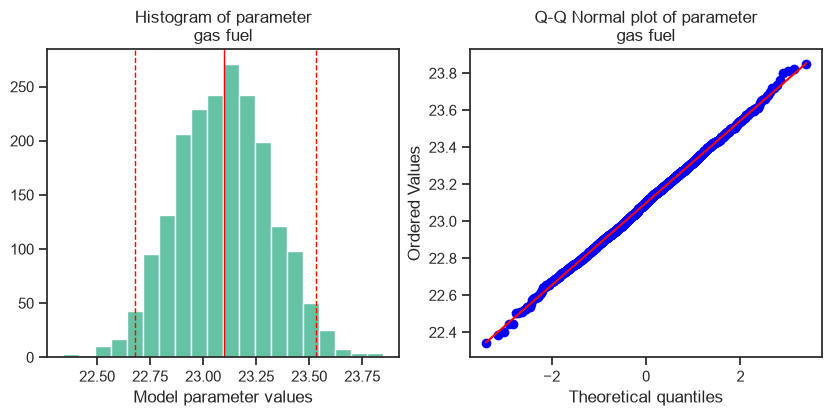

Parameter = curb weight
Mean = -6.411203319965472
Upper confidence interval = -5.845484206541332
Lower confidence interval = -7.001330058646033


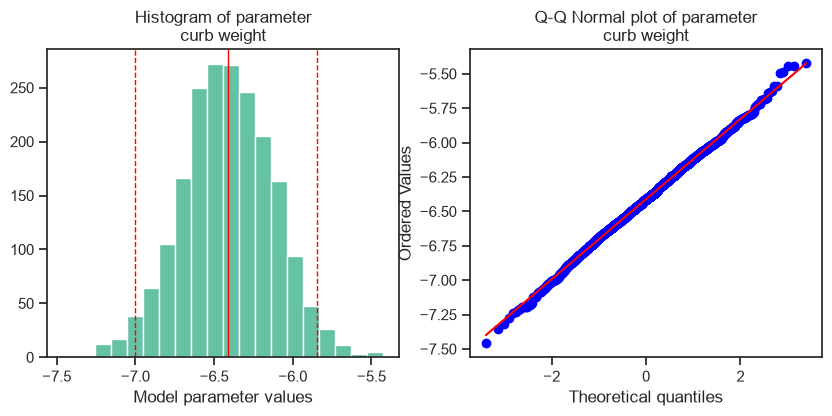

Parameter = curb weight squared
Mean = 1.3190868374647893
Upper confidence interval = 1.710764798970695
Lower confidence interval = 0.9639046157000452


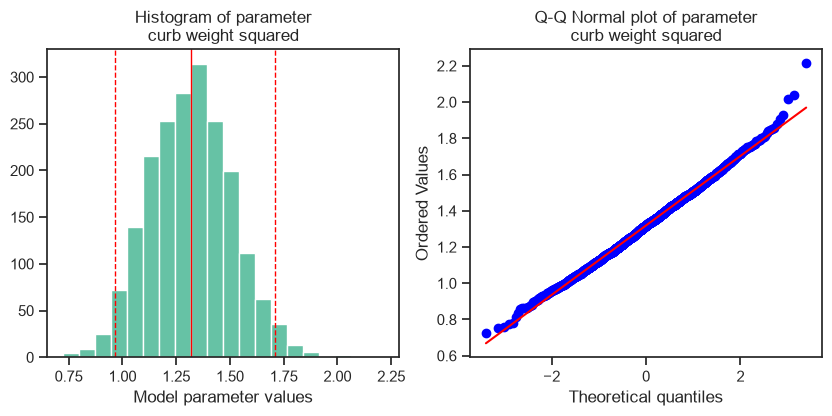

In [14]:
def resample_regression(df, n_boots, n_params=2, formula='y ~ x'):
    ## array to hold the bootstrap samples of the parameters
    boot_samples = np.zeros((n_boots,n_params))
    n_samples = df.shape[0]
    ## Loop over the number of resamples
    for i in range(n_boots):
        ## Create a bootstrap sample of the data frame
        boot_sample = df.sample(n=n_samples, replace=True)
        ## Compute the OLS model
        boot_model = smf.ols(formula=formula, data=boot_sample).fit()
        ## Save the model parameters in the array
        boot_samples[i,:] = boot_model._results.params
    return boot_samples

def compute_CI(values, parameter, p=0.05):   
    mean = np.mean(values)
    p = 100 * p / 2.0
    UCI = np.percentile(values, 100 - p)
    LCI = np.percentile(values, p)
    print('Parameter = ' + parameter)
    print(f'Mean = {mean}')
    print(f'Upper confidence interval = {UCI}')
    print(f'Lower confidence interval = {LCI}')
    return(mean, UCI, LCI)

def plot_boot_params(params, parameter='intercept'):
    mean, UCI, LCI = compute_CI(params, parameter)
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    ## Plot a histogram
    ax[0].hist(params, bins=20)
    ax[0].axvline(mean, color='red', linewidth=1)
    ax[0].axvline(UCI, color='red', linewidth=1, linestyle='--')
    ax[0].axvline(LCI, color='red', linewidth=1, linestyle='--')
     
    ax[0].set_title('Histogram of parameter\n' + parameter)
    ax[0].set_xlabel('Model parameter values')
    ## Plot the Q-Q Normal plot
    ss.probplot(params, plot = ax[1])
    ax[1].set_title('Q-Q Normal plot of parameter\n' + parameter)
    plt.show()

param_boots = resample_regression(auto_data, 2000, n_params=4, formula=formula)
for i,parameter in enumerate(['diesel fuel', 'gas fuel','curb weight', 'curb weight squared']):  
    plot_boot_params(param_boots[:,i], parameter=parameter)

We can also get a feel for the variability of the model by bootstrap resampling the fit and examining the results. To do so, execute the code in the cell below and examine the results. This code computes and displays 100 samples of the bootstrapped regression fit line. There are two unusual aspects of this code. First, the line plot uses the `hue_order` argument to ensure that line hue corresponds to the correct cases. Second, the bootstrap code in wrapped in a `with` statement to suppress printing the model convergence summary 100 times. Executing the resampling algorithm and displaying the lines with Seaborn may take some time.   

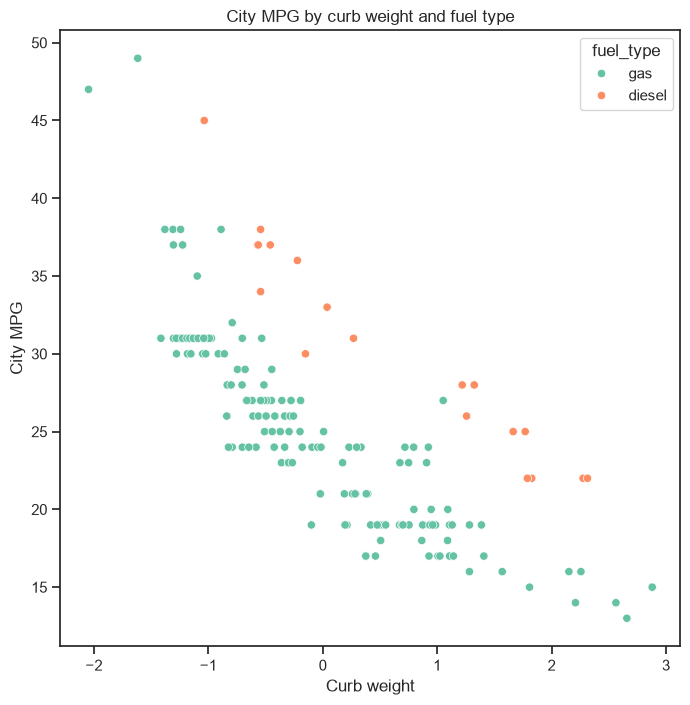

In [15]:
def resample_regression_ols(df, formula,  ax, n_params=4, n_boots=100):
    ## array to hold the bootstrap samples of the parameters
    n_samples = df.shape[0]
    ## Loop over| the number of resamples
    for i in range(n_boots):
        ## Create a bootstrap sample of the data frame
        boot_sample = df.sample(n=n_samples, replace=True)
        boot_sample.index = range(len(boot_sample))

        ## Compute the OLS model
        boot_model = smf.ols(formula=formula, data=boot_sample).fit()    
        boot_sample.loc[:,'predicted'] = boot_model.predict(boot_sample)
        sns.lineplot(x='curb_weight', y='predicted', hue='fuel_type', hue_order=['gas','diesel'], data=boot_sample, ax=ax, alpha=0.1, legend=False);

ax = plot_auto()
with contextlib.redirect_stdout(io.StringIO()):
    resample_regression_ols(auto_data, formula, ax)

There are several observations one can make about these results:    
1. The distribution of the model parameters is generally close to Normal, with a few deviations.      
2. Cis are similar but not identical to the parametric estimates given in the model summary table. The difference being the nonparametric bootstrap estimates make no assumption about the distribution of the model parameters.   
3. The CIs are narrow for the fuel type coefficients, which makes sense since these values represent means that can be estimated with fairly low variance. The CIs for the slope coefficients are relatively wider, particularly for the squared terms, which is expected since slope is more sensitive to random variation in the sample.    
4. The variation in the bootstrap regression lines is reasonably small. As is often the case, the dispersion of the regression lines increases at the ends of the range of the independent variables.     

> **Exercise 22-3:** The results of the `city_mpg_ols` model in Exercise 22-1, included the contrast for the MPG of diesel cars. This contrast vlaue can now be used as an **adjustment factor** for the efficiency of diesel cars.
> The code in the cell below displays the coefficients computed for this model. The second coefficient is the adjustment factor for the efficiency of diesel cars.    

In [16]:
city_mpg_ols._results.params

array([32.36550908, -9.24900594, -6.42798602,  1.30923984])

> To continue with this analysis do the following:     
> 1. Create a new column named `city_mpg_adjusted`. Compute and save the adjusted city MPG into this column.   
> 2. Create a new column named `predicted_adjusted`. Compute and save the adjusted prediction of city MPG into this column.     
> 3. On a single plot display the observations of city mpg vs. standardized curb weight, using `fuel_type` for the hue along with the predictions using `fuel_type` for hue. Make sure you properly lable your plot.    

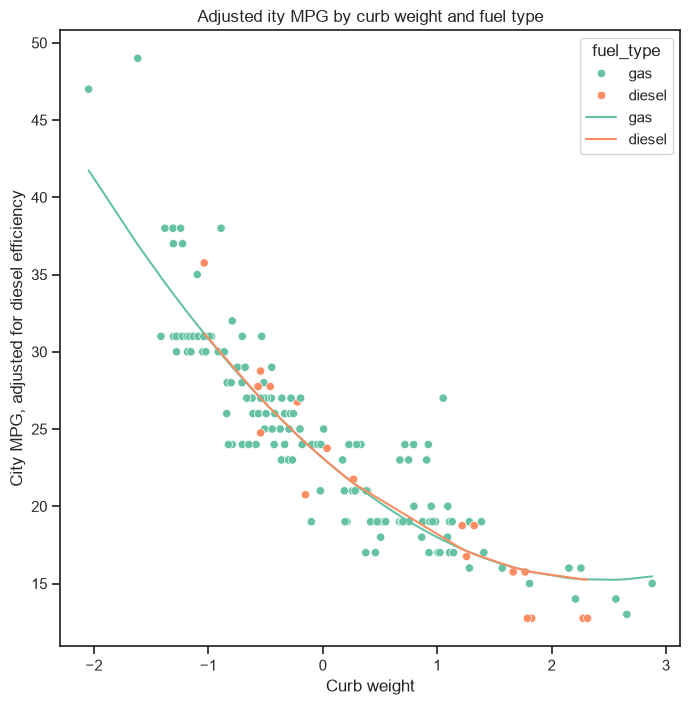

In [17]:
## Put your code below
## Adjust the city_mpg variable for diesel efficiency


## Adjust the predictions for diesel efficiency   


## Plot the results 
fig,ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x='curb_weight', y='city_mpg_adjusted', hue='fuel_type', data=auto_data, ax=ax);
sns.lineplot(x='curb_weight', y='predicted_adjusted', hue='fuel_type', data=auto_data, ax=ax)
ax.set_title('Adjusted ity MPG by curb weight and fuel type');
ax.set_xlabel('Curb weight')
ax.set_ylabel('City MPG, adjusted for diesel efficiency');
plt.show()

> Examine your plot. Does it appear that the the adjustment for diesel car efficiency has aligned the observations for diesel and gas cars and why?   

> **Answer:**     

## Generalize Linear Model

Until now, we have been working strictly with linear regression models. Linear regression models have a numeric label or response variable. Further, ordinary linear regression assumes the residuals of the model are Normally distributed. 

But, what if the label has another distribution, particularly if the label is categorical? Using a more general form for the label values leads us to the **generalized linear model (GLM)**. Generalized linear model can be constructed for any response variable distribution in the exponential family. The exponential family includes many of the most commonly used probability distributions.    

GLMs are created by observing that for any distribution in the exponential we can define a **link function**. The link function maps a linear model space to the log of the (nonlinear) distribution space. The general form of the link function, $g()$, maps the expected value of the response variable, $y$, given the observation vector, $x$, to a linear model $\hat{\lambda} = \beta_0 + \beta_1\ x$:   

$$g \big( \mathtt{E}[y_i|x_i] \big)  = \hat{\lambda} = \beta_0 + \beta_1\ x$$

To find the value of the response variable we apply the inverse link function:    

$$\mathtt{E}[y_i|x_i]   = g^{-1} \big( \hat{\lambda} \big) = g^{-1} \big( \beta_0 + \beta_1\ x \big) $$

You may well wonder what the link function is for the Normal distribution, which is a member of the exponential family. In this case the link function and the inverse link functions are both unity or 1. This property leads to the ordinary least squares model with a Normally distributed response, we have already investigated.    

### Logistic Regression as a GLM

Now, we will look at a widely used variation of the generalized linear model using a **Binomial distribution**. This method is commonly known as [**logistic regression**](https://en.wikipedia.org/wiki/Logistic_regression). Logistic regression is widely used as a classification model. Logistic regression is linear model, with a binary response or label values, `{False, True}` or `{0, 1}`.  specifically, the response is computed as a log likelihood, leading to a Binomial distribution of the label values. 

The logistic regression algorithm is in the family of [**generalized liner models (GLM)**](https://en.wikipedia.org/wiki/Generalized_linear_model). GLMs use a transformation function to map a nonlinear function of probability to a linear model space, known as a **link function**. The **inverse link function** maps the linear model response to the nonlinear model space. 

To understand the binary response logistic regression as a GLM, we start with a model for the log-odds of response $1$ vs. $0$, given probability of success, or $y_i = 1$, $p_i$. For independent variable vector $x_i$, model parameter vector, $\mathbf{\beta}$, and binary response, $y_i = [0,1]$, we define the link function, know as the or **logit function**:   

$$logit(\mathtt{E}[y_i|x_i]) = logit(p(x_i)) = ln \Big(\frac{p(x_i)}{1-p(x_i)} \Big) =\beta_0 + \mathbf{\beta} 𝑥_i $$

The response of the linear model is transformed to the binomially distributed probability distribution through the **inverse link function**, know as the **inverse logit function**, or **logistic function**. After some algebra we can arrive at:   

\begin{align}
\lambda_i &= \beta_0 + \mathbf{\beta} 𝑥_i\\
p_i = \mathtt{E}[y_i|x_i] &= f(\lambda_i) = logit^{-1}(\lambda_i)  \\
p_i = f(x_i) &= logit^{-1}(\lambda_i) = \frac{1}{1 + e^{-\lambda_i}} = \frac{1}{1 + e^{-(\beta_0 + \mathbf{\beta} 𝑥_i)}}
\end{align}

We can gain an intuitive understanding of these transformations by creating a graph of the simple one-dimensional of the logistic function, or inverse logit function. The one-dimensional logistic function is parameterized by an center, $x_0$, and slope, $\kappa$.   

$$f(x)  = \frac{1}{1 + e^{-\kappa(x - x_0)}}$$

To simplify the example, we set $x_0 =0$ and $\kappa=1$. Execute the code in the cell below to compute and plot an example of the logistic function.

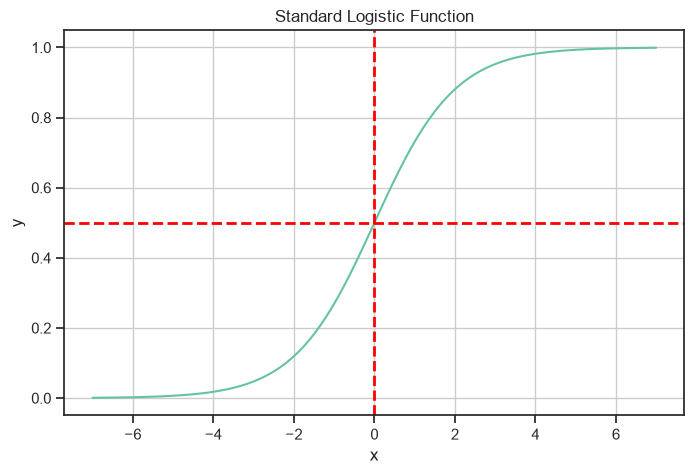

In [18]:
# Plot the logistic transformation function (f(x) above)
x_seq = np.linspace(-7, 7, 100)

def log_fun(x, center=0, scale=1):
    e = np.exp(-scale*(x-center))
    log_out = 1./(1. + e)
    return log_out

log_fun_vectorized = np.vectorize(log_fun)

log_y = log_fun_vectorized(x_seq)

fig,ax = plt.subplots(figsize=(8,5))
ax.plot(x_seq, log_y)
ax.set_title('Standard Logistic Function')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.axvline(0, color='red', linewidth=2, linestyle='--')
ax.axhline(0.5, color='red', linewidth=2, linestyle='--')
ax.grid()
plt.show()

You can see that the logistic function crosses the threshold value of $0.5$ at $x=0$. A linear response greater than the threshold gives a model output of 1 and vice versa.        

Let's make this a bit more concrete with a simple example. Say we have a linear model with an intercept, $\beta_0$, and slope parameter, $\beta_1$.

$$\hat{\lambda} = \beta_0 + \beta_1\ x$$

Now, depending on the value of $\hat{y}$ we want to classify the output from a logistic regression model as either `0` or `1`. We can use the linear model in the logistic function as follows:

$$f(\hat{y}) = \frac{1}{1 + e^{-\lambda}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1\ x)}} $$

In this way we transform the continuous output of the linear model defined on $-\infty \le \hat{y} \le \infty$ to a binary response, $0 \le f(\hat{y}) \le 1$ 

### Finding the maximum likelihood solution   

In Chapter 11 we investigated methods for finding maximum likelihood solutions at large scale. These methods are generally based on variations of the stochastic gradient descent (SGD) algorithms or quasi-Newton's methods like the limited memory Broyden–Fletcher–Goldfarb–Shanno (l-BFGS) algorithm. These algorithms are employed routinely to logistic regression problems on a massive scale.     

## What is Deviance?

OLS regression models are often evaluated based on variance ratios, such as the $R^2$ metric, or error metrics like RMSE. However given the nonlinear mapping between the linear model and the response, these methods are not suitable for generalized linear models. The significance of the GLM is expressed in terms of a statistic called **deviance**. It can be a bit of a challenge to wrap your head around what deviance really means. In simple terms, deviance is the difference between the log likelihood of a reference model and some other model. For a model with paramters $f(\phi)$ and a reference model with parameters $f(\phi_r)$, we can write the devaince as:     
$$D \big( f(\mathbf{X},\phi) \big) = 2 \Big( l \big(f(\mathbf{X}, \phi_R) \big) - l \big( f(\mathbf{X}, \phi)\big) \Big)$$    
Where:   
- $\mathbf{X} =$ the array of observations.    
- $l\ \big( f(\mathbf{X}, \phi) \big) = $ the log-likelihood of the model.   

To further complicate the problem there are several commonly used forms of deviance:    
- **Residual deviance** uses a **saturated model** as a referrence. A saturated model has a degree of freedom (parameter) for each observation, leading to a perfect fit.    
- **Residual diviance** uses a **null model** as a reference. A null model explains none of the variance of the data.     

The deviance statistic is $\chi^2$ distributed, and we can apply a significance test on a model.A model with small deviance is little better that informed guessing, and will have a small $\chi^2$ and not be considered a significant improvement. Whereas, a model with large deviance has a large $\chi^2$, demonstrating a significant improvement in accuracy.     

### Residual deviance     

Residual deviance is defined as 2 times the difference between the log likelihood of a saturated model, $f(\mathbf{X}, \phi_S)$, and some other model. We can write can write:      

$$D_R \big( f(\mathbf{X},\phi) \big) = 2 \big( l(f(\mathbf{X}, \phi_S)) - l( f(\mathbf{X}, \phi)\big))$$    

Residual deviance has several important properties.   
- First residual deviance between two identical models must be 0.   
- Second, since the log likelihood of a saturated model will be the maximum possible, $D_R \big( f(\mathbf{X},\phi) \big) \ge 0$.   

What are some simple examples of a saturated model?     

**Normal saturated model:**

We can construct a saturated model for normally distributed values by having a free mean parameter, $u_i$ for each observation, $x_i$.

$$
\begin{bmatrix}
x_1\\
x_2\\
x_3\\
\vdots\\
x_n
\end{bmatrix} = 
\begin{bmatrix}
1, 0, 0, \ldots, 0\\
0, 1, 0, \ldots, 0\\
0, 0, 1, \ldots, 0\\
\vdots,\ \vdots,\ \vdots,\ \ddots,\ \vdots\\
0, 0, 0, \ldots, 1
\end{bmatrix}
\begin{bmatrix}
\mu_1\\
\mu_2\\
\mu_3\\
\vdots\\
\mu_n
\end{bmatrix}
$$

Now, the normal likelihood for this models is   

$$\mathcal{L}(\mathbf{X} |\ \mathbf{\mu}) = -\frac{1}{(2 \pi \sigma^2)^{n/2}} exp\Big[ - \frac{1}{2 \sigma^2}  \sum_{i=1}^n(x_i - \mu_i)^2 \Big]$$

Since $\mu_i = x_i$. The Normal likelihood is $1.0$ and the log likelihood is $0.0$.     

**Binomial saturated model:**

A saturated Binomial model can be constrcuted if for each outcome, $y_i$, with a probability parameter:  

$$ 
\pi_i = 
\begin{cases}
  1 & \text{if $y_i=1$} \\
  0 & \text{if $y_i=0$}
\end{cases}
$$   

The likelihood can be writen:     

$$\prod_{i=1}^{n} \hat{\pi}_i^{y_i} (1 - \hat{\pi}_i)^{1-y_i} = 1^n = 1$$

Since $log(1) = 0$, the log likelihood of the saturated model.     



### Null Deviance    


Null deviance is 2 times the square of the log odds ratio between a model and a null model. Intuitively, the null model is simply informed guessing, and deviance is a measure of how much the model improves accuracy beyond guessing.  

**Binomial null model:**  

To understand binomial deviance, we can start with the expected value of the binomial log-likelihood function:  

$$\hat{l}(k, n | \pi) = log \binom{n}{k} + k\ log(\pi) + (n-k)\ log(1-\pi)$$

We can now construct the log likelihood of the null model, by the simple calculation of the binomial probability:  

$$p_\phi = \bar{y} = \frac{k}{n}$$

For the null model we set $\beta_0 = p_\phi$, so the logistic function for a null model is:    

$$f_{\phi}(\hat{y}) = \frac{1}{1 + e^{-p_{\phi}}} = \frac{1}{1 + e^{-\beta_0}}$$

And with expected log-likelihood:   

$$$\hat{l}_phi(k, n | p_{\phi}) = log \binom{n}{k} + k\ log(p_{\phi}) + (n-k)\ log(1-p_{\phi})$$

We can gain some intuitive understand of the behavior of the null model with an example. Consider the case where half the values of the response, $y$, are 1s. In this case, $p_\phi = n/2 = 0.5$. For each value of $x_i$, the model randomly selects a 1 or a 0 response with probability of 0.5. This model is random guessing and will have an accuracy of 0.5. In other words, the null model is no better in terms of predictive power than just saying that all values of $y$ are either 0 or all values are 1.    

Now that we understand the null model with can state the form of null deviance of a linear model, $logit(p(x_i)) = \beta_0 + \mathbf{\beta} 𝑥_i$, as the log of the square expected likelihood ratio:   

\begin{align}
D(\beta_0 + \mathbf{\beta} 𝑥_i) &= ln \Big( \frac{\hat{L}^2}{\hat{L}_{\phi}^2} \Big) \\
&= 2 \big( \hat{\mathcal{l}}  -  \hat{\mathcal{l}}_{\phi}  \big)
\end{align}

The expected null log-likelihood, $\hat{\mathcal{l}}_{\phi}$, is fixed by the observed response values. Therefore, the better the model, and higher the likelihood, $\hat{\mathcal{l}}$, the higher the deviance and therefore the value of $\chi^2$. Correspondingly, a model with large $\chi^2$ has greater significance and accuracy of predictions.    

In this section, we have focused on the logistic regression problem and binomial log-likelihood. The concepts discussed in this section can be applied to any GLM. In some cases, deviance can be used directly. In other cases log-likelihood ratio is used directly for model evaluation and significance.   

### Pearson residuals        

Another way to examine results of a GLM model is to use **Pearson residuals**. Pearson residuals are standardized by the empirical standard deviation. For the ith response $y_i$ and the estimated probability from the model, $\hat{p_i}$ the raw residual is:   

$$r_i = y_i - \hat{p_i}$$

and the standard deviation is:   
$$var_i = \hat{p_i}(1-\hat{p_i})$$

The Pearson residual is computed:      

$$r_p = \frac{y_i - \hat{p_i}}{\sqrt{\hat{p_i}(1-\hat{p_i})}}$$



### Evaluating the performance of binary responses

To evaluate models with binary output we can build a **confusion matrix** or **truth table** from counts. These counts are defined:ng

 - True Positives (TP): Count of cases that are positive and predicted to be positive.
 - True Negatives (TN): Count of cases that are negative and predicted to be negative.
 - False Positives (FP): Count of cases that are negative and predicted to be positive.
 - False Negatives (FN): Count of cases that are positive and predicted to be negative.

The other metrics are defined as follows:

- Accuracy = (TP + TN) / (TP + FP + TN + FN)
- Precision = TP / (TP + FP)
   - Precision is the fraction of the relevant class predictions are actually correct.
- Recall = TP / (TP + FN)
   - Recall is the fraction of the relevant class were we able to predict.

## Logistic Regression Example     

It's time to apply the foregoing theory to a practical problem. The goal for the analysis of the [HR dataset from Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/hr-analytics-case-study) is to help a company identify which employees are most likely to leave. Apparently, these data were generated based on a simulation based on real-world cases. 

As a first step, the data is loaded and standardized. The binary response variable is `left`, did the employee leave the company. Execute the code below to prepare the dataset.  

In [19]:
hr_data = pd.read_csv('../data/HR_comma_sep.csv')

print(hr_data.select_dtypes(include=["float"]).columns)

int_cols = ['number_project', 'average_montly_hours', 'time_spend_company'] # hr_data.select_dtypes(include=["int64"]).columns
hr_data[int_cols] = hr_data[int_cols].astype("float")

float_columns = ['number_project', 'average_montly_hours', 'time_spend_company',
                 'satisfaction_level', 'last_evaluation']
for col in float_columns: # hr_data.select_dtypes(include=["float"]).columns:
    hr_data.loc[:,col] = np.divide(hr_data.loc[:,col] - np.mean(hr_data.loc[:,col]), np.std(hr_data.loc[:,col]))
hr_data.head()

Index(['satisfaction_level', 'last_evaluation'], dtype='str')


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,-0.936495,-1.087275,-1.462863,-0.882040,-0.341235,0,1,0,sales,low
1,0.752814,0.840707,0.971113,1.220423,1.713436,0,1,0,sales,medium
2,-2.022479,0.957554,2.593763,1.420657,0.343655,0,1,0,sales,medium
3,0.431041,0.899131,0.971113,0.439508,1.028546,0,1,0,sales,low
4,-0.976716,-1.145699,-1.462863,-0.841993,-0.341235,0,1,0,sales,low


You can see that the numeric variables have all been standardized.  

### Dataset exploration and transformation

Before starting any modeling we need to perform some exploration of the dataset. In this case we will only take some basic steps. A more through job would is required for serious analysis.   

As a first step, execute the code in the cell below to display histograms of the variables. For each variable a facet plot is created grouped by the response variable. These facet plots allow visualization of the difference in distributions between the two categories of the response.  

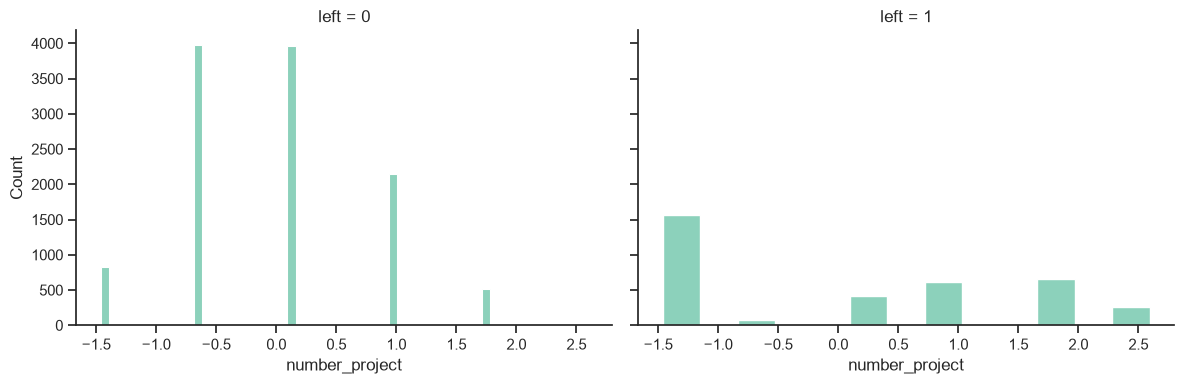

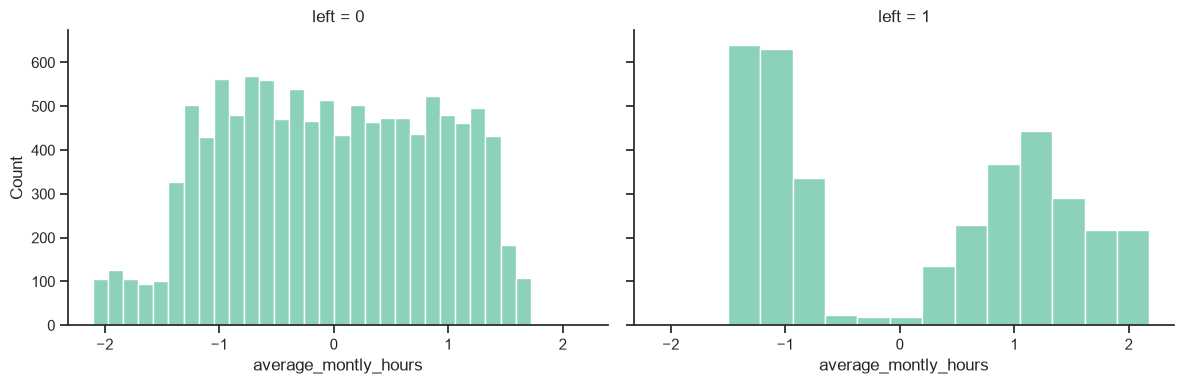

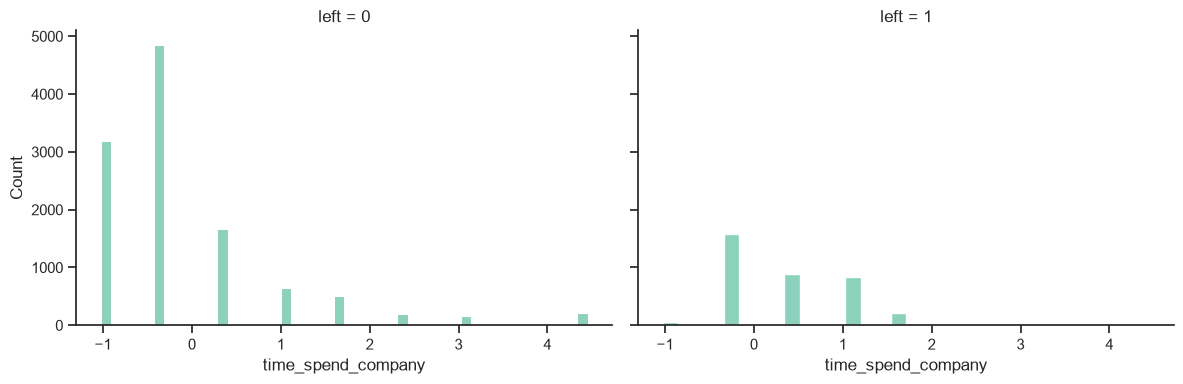

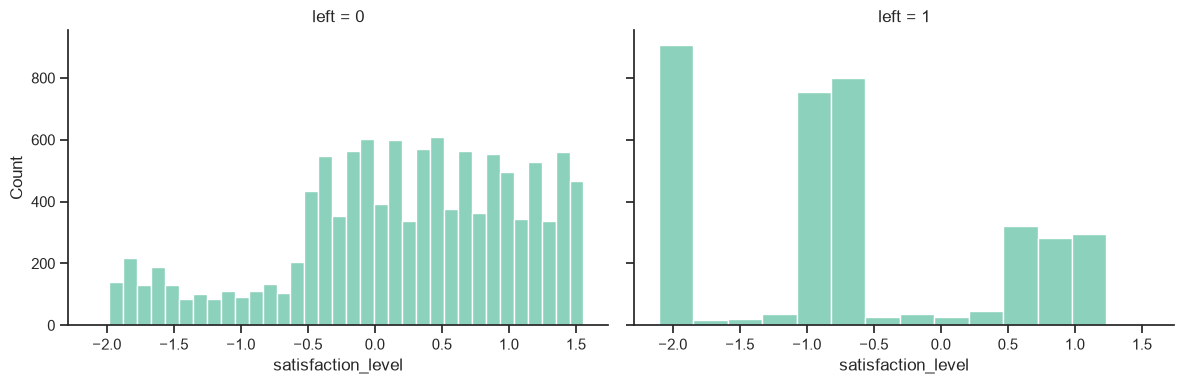

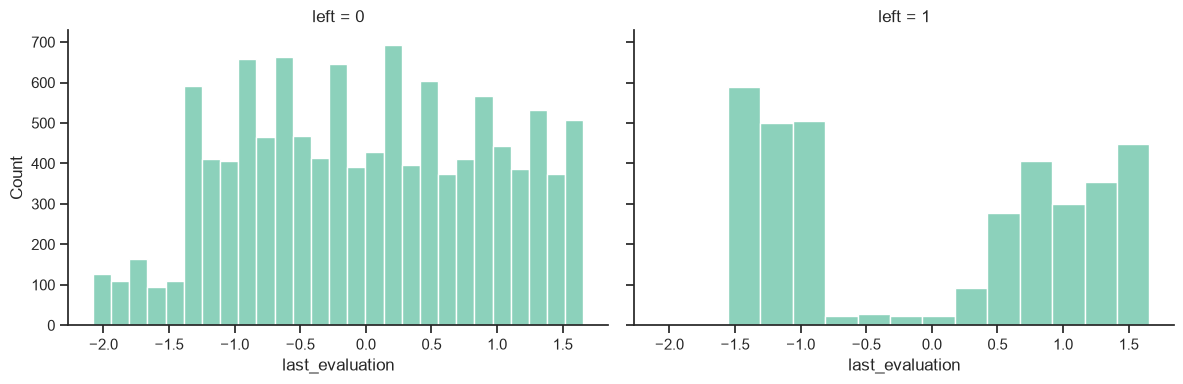

In [20]:
for col in float_columns:
    g = sns.FacetGrid(hr_data, col='left', height=4, aspect=1.5, subplot_kws={'alpha':0.1})
    g.map_dataframe(sns.histplot, x=col)
    plt.show()

These distributions are far from Normal. Perhaps we can improve the situation by applying the [Yeo-Johnson power transformation](https://en.wikipedia.org/wiki/Power_transform). Execute the code in the cell below to apply this transformation and display faceted histograms of the result.   

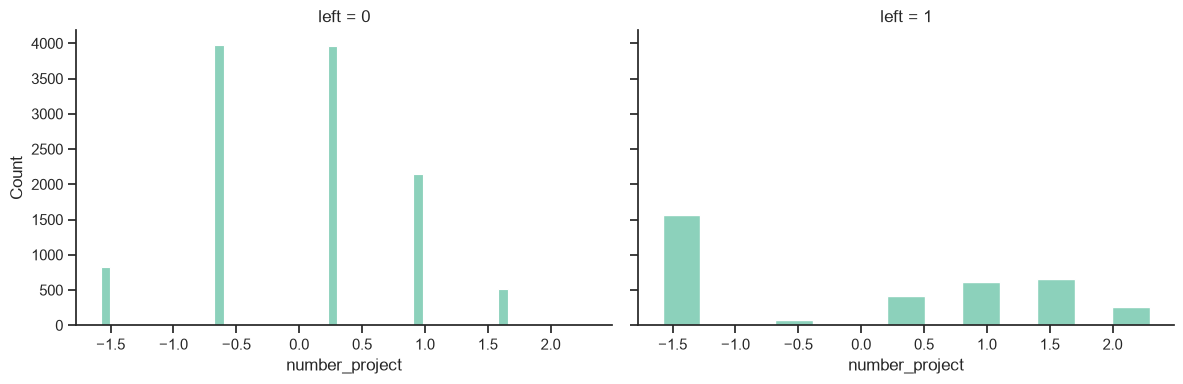

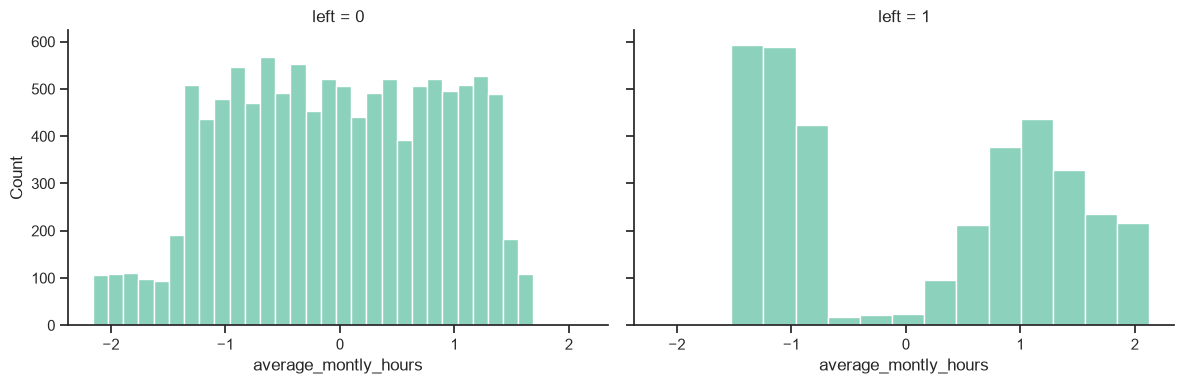

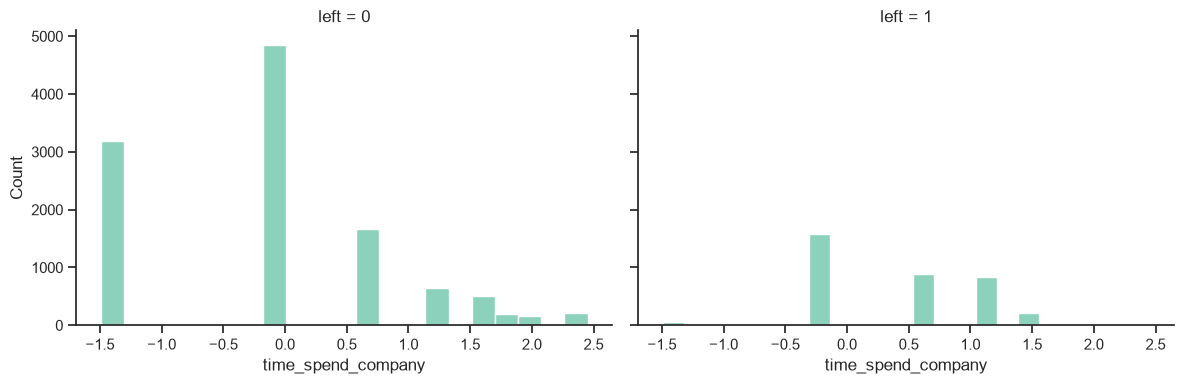

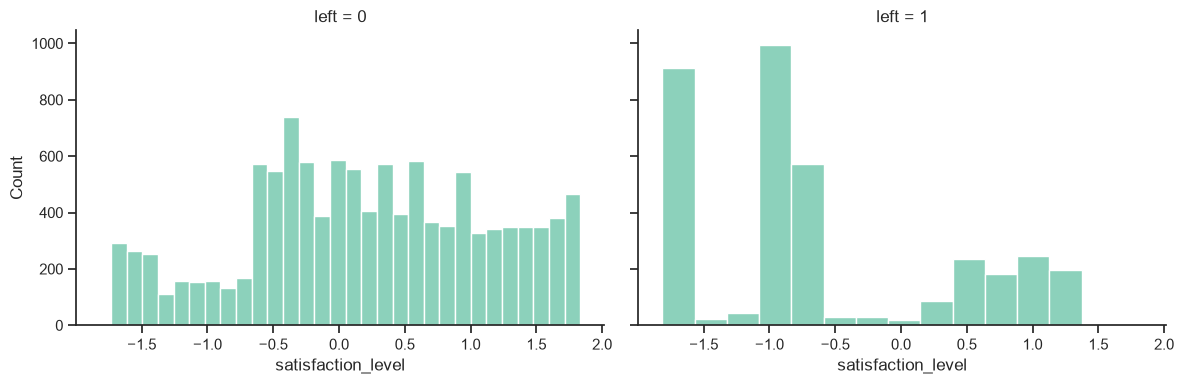

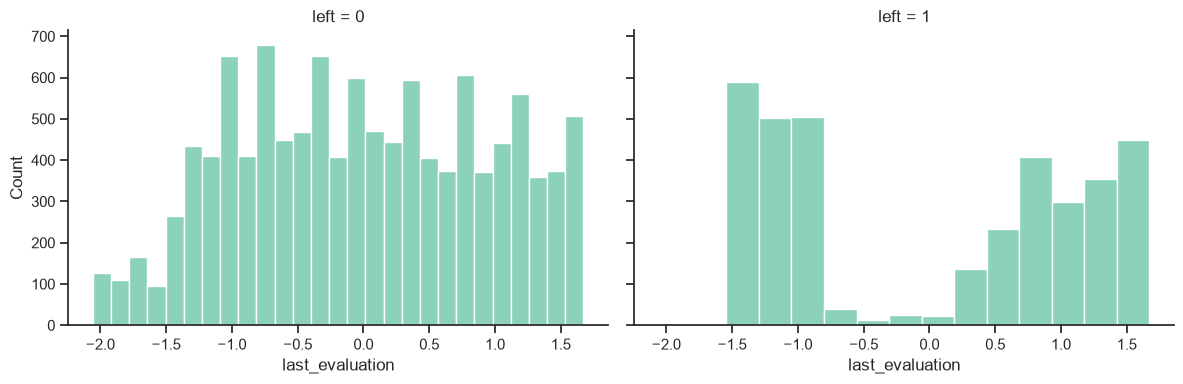

In [21]:
from sklearn.preprocessing import PowerTransformer

YJ_transform = PowerTransformer(method='yeo-johnson', standardize=True)
hr_data[float_columns] = YJ_transform.fit_transform(hr_data[float_columns])

for col in float_columns:
    g = sns.FacetGrid(hr_data, col='left', height=4, aspect=1.5, subplot_kws={'alpha':0.1})
    g.map_dataframe(sns.histplot, x=col)
    plt.show()

The transformation has not changed the distributions a great deal. There are some slight improvements so we will use the transformed variables.     

### Interaction effects

In many cases, the variables in a dataset have [**interaction effects**](https://en.wikipedia.org/wiki/Interaction_(statistics)). If not accounted for, statistically significant interaction effects can confound main effects and lead to incorrect inferences about a model. A common symptom of a missing interaction effect are non-Normal error distributions for parameter estimates and the residuals.    

To understand interaction effects consider a linear model with a response $y$ and two independent variables $x_1$ and $x_2$. If $x_1$ and $x_2$ are statistically independent, we can write the regression equation as:   
$$y = a + b x_1 + c x_2 + \epsilon$$

Where $a$ is the intercept term, $b$ and $c$ are the coefficients parameterizing the main effects and $\epsilon ~ N(0,\sigma^2)$ are the normally-distributed zero-mean residuals. 

Now, consider a model where x_1$ and $x_2$ are not independent but have an interaction. In this case the total effect depends on the product of x_1$ and $x_2$ as well as the main effects. The regression model can then be expressed as:     

$$y = a + b x_1 + c x_2 + d (x_1 \times x_2) + \epsilon$$     

Interaction plots are a widely used tool for exploration for interaction effects. One (often continuous) variable is plotted on the vertical axis. The value of another variable is plotted on the horizontal axis. Lines and markers of different characteristics  representing the response are shown on the plot. 

Execute the code in the cell below to display the interaction plots for the independent variables in the dataset.   

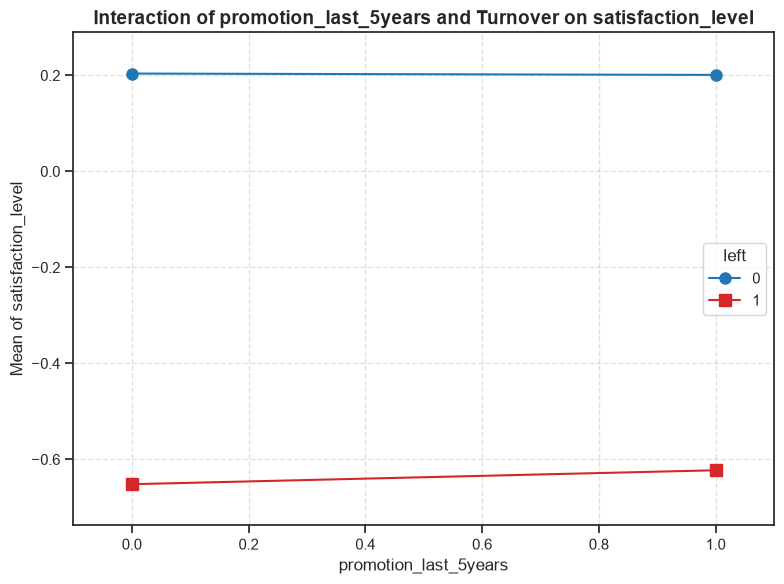

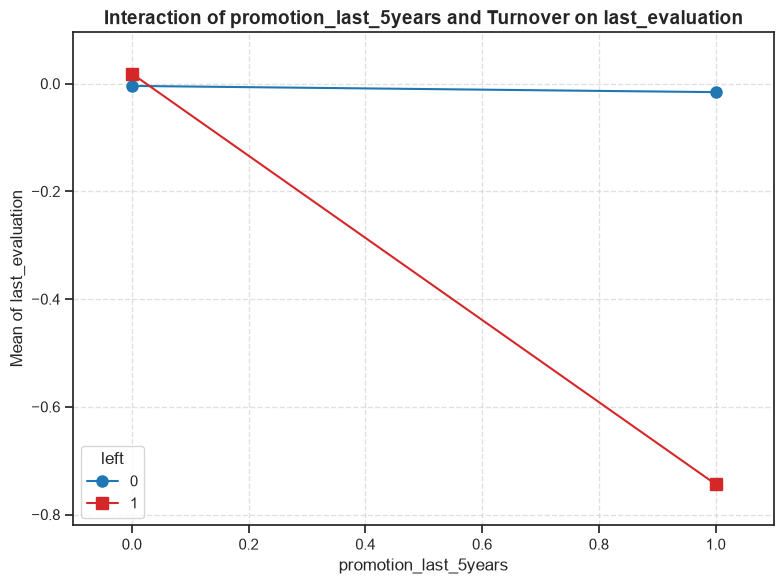

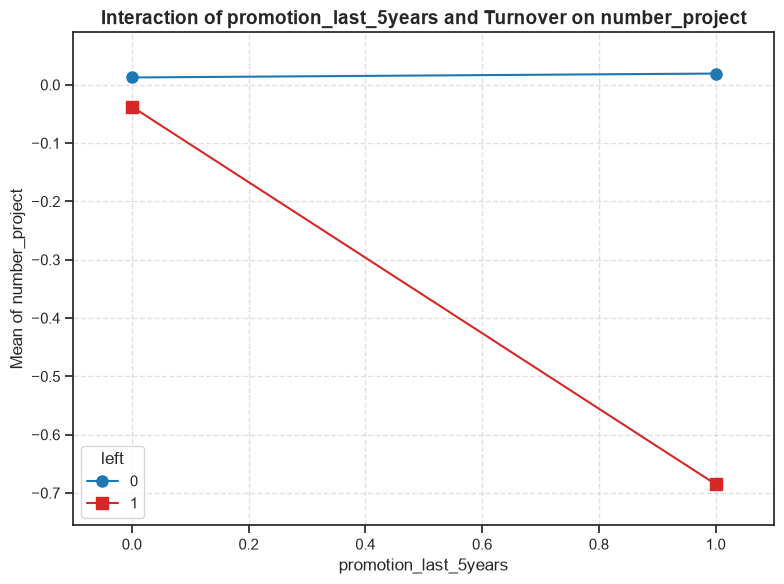

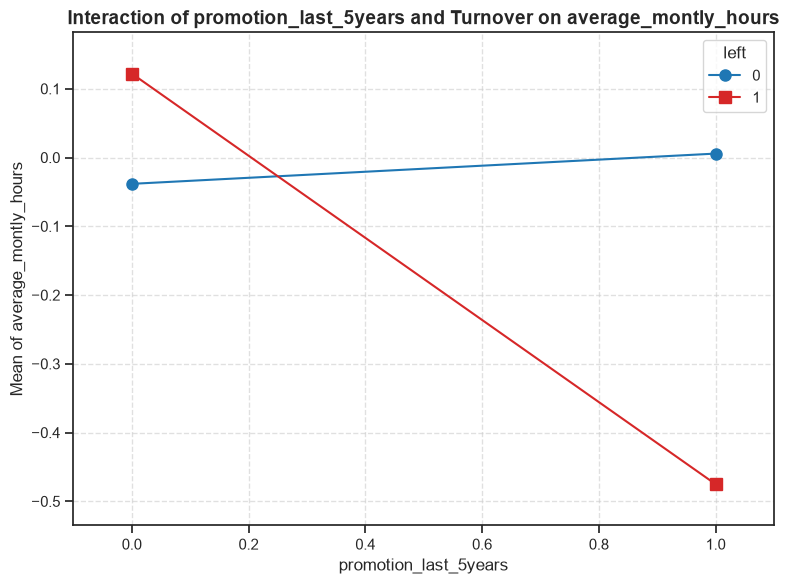

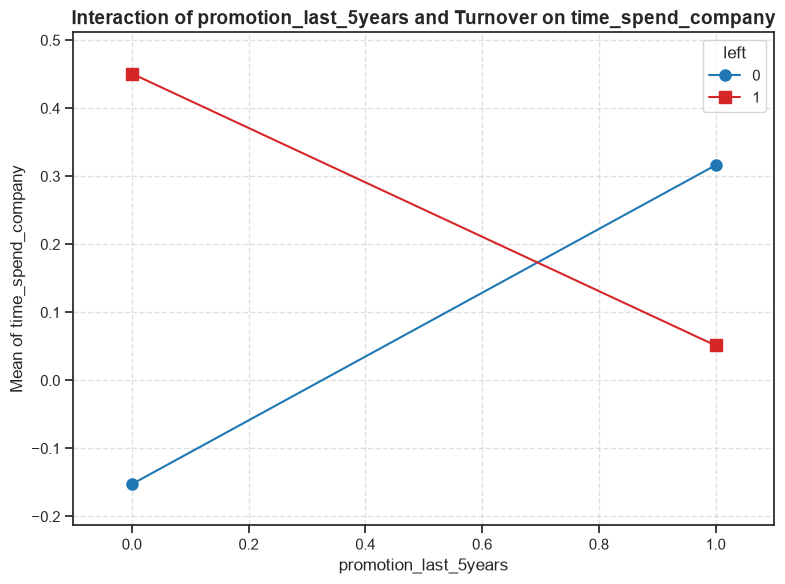

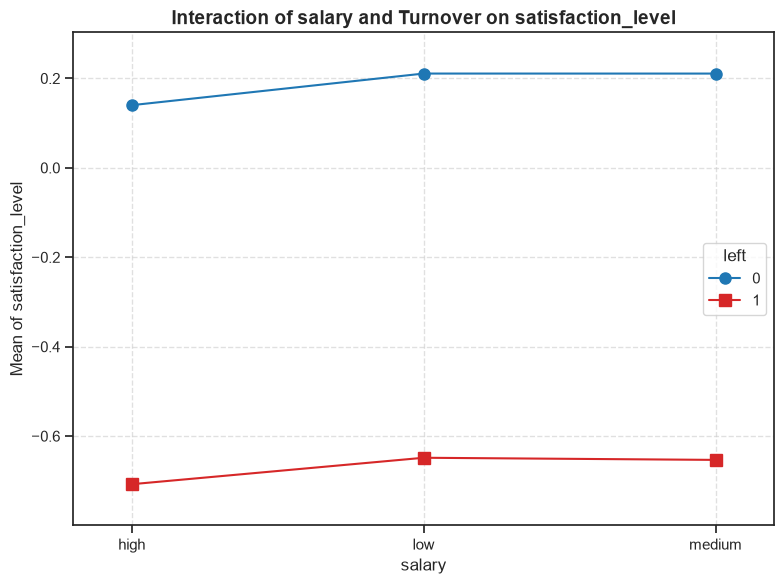

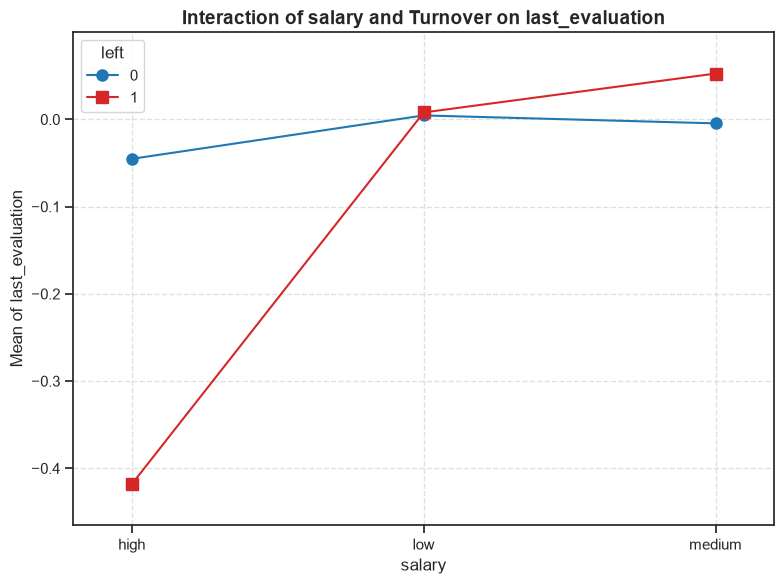

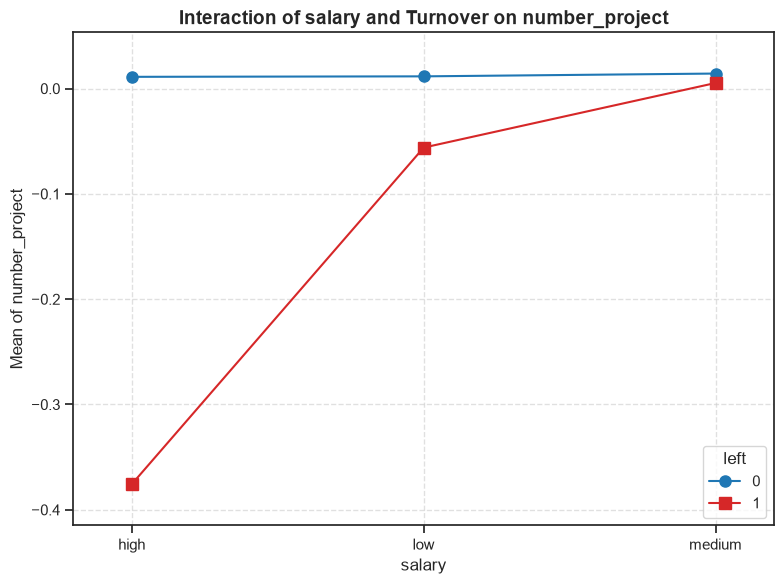

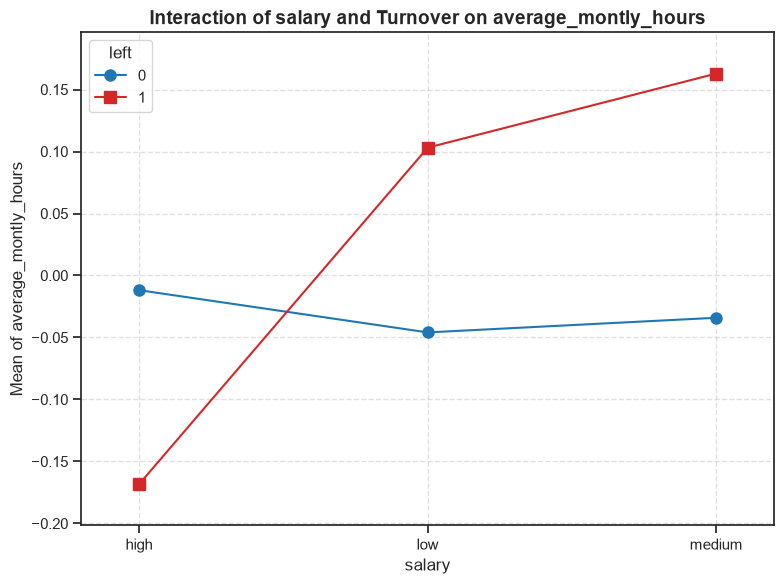

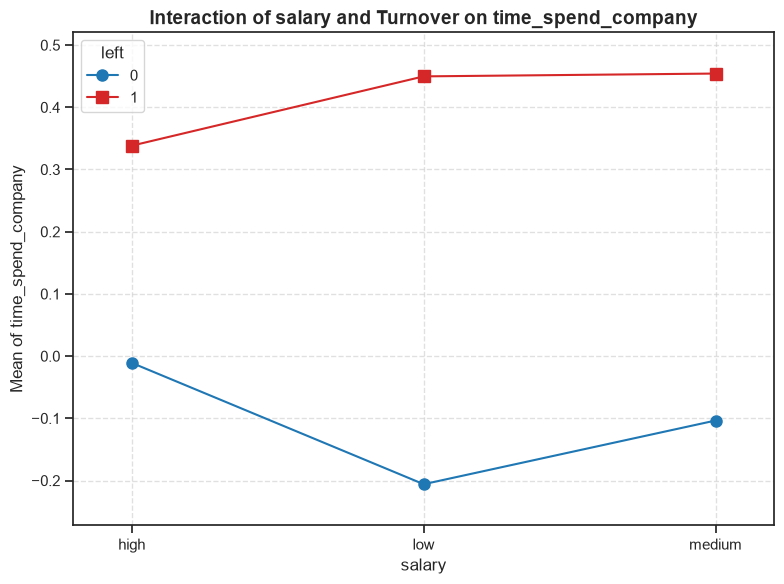

In [22]:
# 1. Properly separate your columns by their functional type
categorical_x = ['promotion_last_5years', 'salary']

continuous_responses = [
    'satisfaction_level', 'last_evaluation', 
    'number_project', 'average_montly_hours', 'time_spend_company'
]

# 2. Loop through all valid combinations
for var1 in categorical_x:
    for var2 in continuous_responses:
        fig, ax = plt.subplots(figsize=(8, 6))

        # Generate the interaction plot using statsmodels
        interaction_plot(
            x=hr_data[var1],             # X-axis gets the categorical factor
            trace=hr_data['left'],       # Line split remains the turnover flag
            response=hr_data[var2],      # Response gets the purely numeric target
            colors=['#1f77b4', '#d62728'],       
            markers=['o', 's'],                  
            ms=8,                                
            ax=ax                                
        )

        # Enhance readability and visual polish
        ax.set_title(f'Interaction of {var1} and Turnover on {var2}', fontsize=14, fontweight='bold')
        ax.set_xlabel(var1, fontsize=12)       
        ax.set_ylabel(f'Mean of {var2}', fontsize=12) # Clarified that this tracks the mean
        ax.grid(True, linestyle='--', alpha=0.6)
        
        plt.tight_layout()
        plt.show()

Interpretation of interaction plots is generally straight forward but requires some judgment. If the lines on the plot are parallel, this indicate the difference in the effect of one variable on the other is constant, or no interaction. If the lines have different slopes, or changing slopes there is evidence of an interaction effect between the variables. 

Detecting the presence of lines with differing slopes on a plot does not indicate that the interaction is statistically significant, only that it is present. Modeling is required to verify interaction terms are statistically significant.  

> **Exercise 22-4:** The question is which variable pairs have interactions.
> 1. Classify each of the variable pairs as having little or no interaction, moderate interaction, or strong interaction. This process will require applying some judgment.    
> 2. Why is it not possible to determine if the interactions observed in these charts are significant?

> **Answer:**
> 1.  
>     a:     
>     b:     
>     c:            
> 2.      

### Building a model 

With a bit of EDA completed, we are now ready to construct a first model. 

> **Exercise 22-5:** To create and evaluate a logistic regression model for the HR data, do the following:         
> 1. Define and fit a model using the variables satisfaction_level, average_montly_hours, last_evaluation, salary, promotion_last_5years, number_project, and time_spend_company plus the pairs of these variables that exhibit interaction. Make sure you correctly code the categorical variables.     
> 2. Print a summary of the fitted model.    

In [23]:
# Convert Arrow string columns to pandas object
string_cols = hr_data.select_dtypes(include=["string"]).columns
hr_data[string_cols] = hr_data[string_cols].astype("object")

## Put your code below







<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                   left   No. Observations:                14999
Model:                            GLM   Df Residuals:                    14979
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6323.5
Date:                Sun, 20 Sep 2026   Deviance:                       12647.
Time:                        08:54:38   Pearson chi2:                 1.36e+04
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2247
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -3.0967      0.141    -21.967      0.000      -3.373      -2.820
C(salary)[T.low]                               1.8207      0.144     12.658      0.000       1.539       2.103
C(salary)[T.medium]                            1.3942      0.145      9.623      0.000       1.110       1.678
C(promotion_last_5years)[T.1]                 -1.5001      0.311     -4.822      0.000      -2.110      -0.890
satisfaction_level                            -1.0223      0.026    -39.648      0.000      -1.073      -0.972
average_montly_hours                           0.0880      0.128      0.690      0.491      -0.162       0.338
salary[T.low]:average_montly_hours             0.1763      0.132      1.331      0.183      -0.083       0.436
salary[T.medium]:average_montly_hours          0.2051      0.134      1.534      0.125      -0.057       0.467
last_evaluation                               -0.2779      0.137     -2.025      0.043      -0.547      -0.009
salary[T.low]:last_evaluation                  0.4270      0.142      3.013      0.003       0.149       0.705
salary[T.medium]:last_evaluation               0.4597      0.142      3.228      0.001       0.181       0.739
number_project                                -0.5463      0.131     -4.169      0.000      -0.803      -0.289
salary[T.low]:number_project                  -0.0305      0.136     -0.225      0.822      -0.297       0.236
salary[T.medium]:number_project                0.0575      0.137      0.420      0.674      -0.211       0.326
time_spend_company                             0.3111      0.112      2.786      0.005       0.092       0.530
salary[T.low]:time_spend_company               0.6368      0.119      5.373      0.000       0.404       0.869
salary[T.medium]:time_spend_company            0.2674      0.118      2.267      0.023       0.036       0.499
promotion_last_5years:time_spend_company      -0.8953      0.234     -3.829      0.000      -1.354      -0.437
promotion_last_5years:last_evaluation         -0.5375      0.301     -1.784      0.074      -1.128       0.053
promotion_last_5years:average_montly_hours    -0.3180      0.289     -1.102      0.270      -0.884       0.248
==============================================================================================================
"""

> What evidence can you cite that this model is over-fit? You can answer this question in general terms. There is no need to provide an exhaustive feature-by-feature evaluations. 

> **Answer:**    

> **Exercise 22-6:** Some features of the preceding model need to be pruned to create a model that is not over-fit. There are several ways we could undertake this process. We could try to apply [**stepwise regression**](https://en.wikipedia.org/wiki/Stepwise_regression). In this case a manual pruning process was used. The process was facilitated by noticing that many of the over-fit direct effect parameters occurred in multiple over-fit interaction terms.
>
> To save you the search effort, you can removed (comment out if you prefer) all of the interaction terms except salary and last evaluation, promotion last 5 years and last evaluation. The execute your code and print a summary.     

In [24]:
## Put your code below





<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                   left   No. Observations:                14999
Model:                            GLM   Df Residuals:                    14987
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6366.4
Date:                Sun, 20 Sep 2026   Deviance:                       12733.
Time:                        08:54:39   Pearson chi2:                 1.32e+04
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2203
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -3.3384      0.136    -24.488      0.000      -3.606      -3.071
C(salary)[T.low]                          2.1248      0.138     15.449      0.000       1.855       2.394
C(salary)[T.medium]                       1.5864      0.138     11.461      0.000       1.315       1.858
C(promotion_last_5years)[T.1]            -1.9970      0.312     -6.410      0.000      -2.608      -1.386
satisfaction_level                       -1.0136      0.026    -39.676      0.000      -1.064      -0.964
average_montly_hours                      0.2685      0.026     10.317      0.000       0.217       0.320
last_evaluation                          -0.4290      0.132     -3.261      0.001      -0.687      -0.171
salary[T.low]:last_evaluation             0.5909      0.134      4.394      0.000       0.327       0.855
salary[T.medium]:last_evaluation          0.6176      0.136      4.558      0.000       0.352       0.883
number_project                           -0.5287      0.027    -19.794      0.000      -0.581      -0.476
time_spend_company                        0.7324      0.027     27.577      0.000       0.680       0.784
promotion_last_5years:last_evaluation    -0.6815      0.264     -2.585      0.010      -1.198      -0.165
=========================================================================================================
"""

> This model is not over-fit. Examine the summary and answer these questions.
> 1. Given the performance statistics in the summary is there a difference in model fit compared to the over-fit model and why?
> 2. Examine the categorical variables. What variable values does the intercept term represent?  

> **Answers:**
> 1.         
> 2.     

### Evaluate model performance

Next, you will evaluate the predictions of the 

> **Exercise 22-7:** The predictions from the model are **binomially distributed**. Execute the code in the cell below to compute and display these probabilities. The code displays the first 5 rows of the prediction probability along with a histogram of the probabilities for all cases and a violin plot by leaving status.    

Probabilities of leaving:
   predicted_prob  left
0        0.521364     1
1        0.199505     1
2        0.468957     1
3        0.281735     1
4        0.529849     1
5        0.484295     1


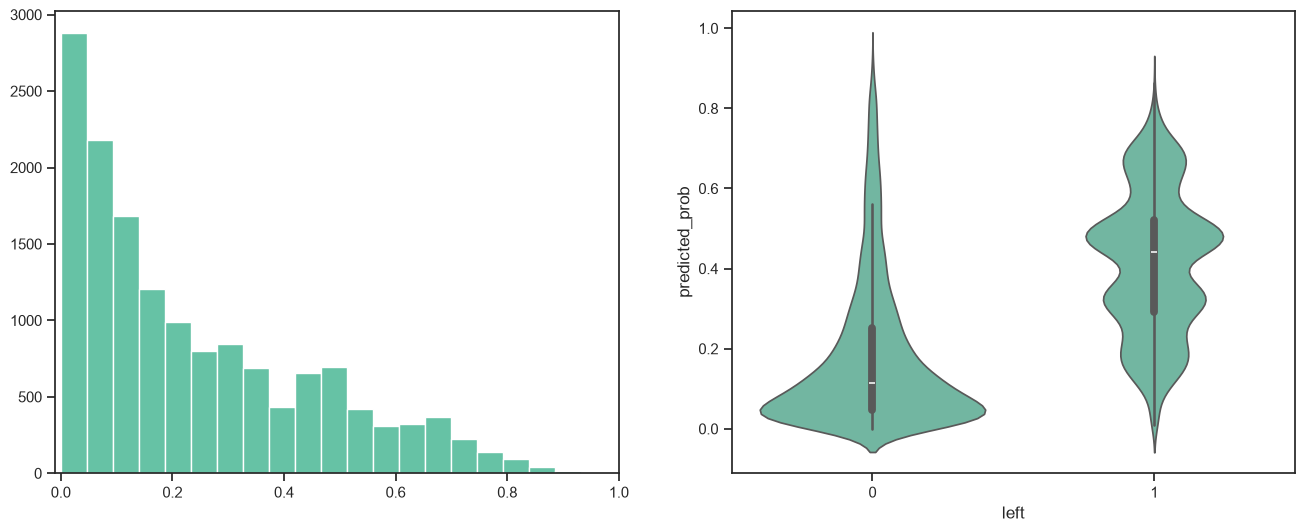

In [25]:
hr_data.loc[:,'predicted_prob'] = hr_glm.predict(hr_data)
print('Probabilities of leaving:')
print(hr_data.loc[:5,['predicted_prob', 'left']])

fig,ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].hist(hr_data.loc[:,'predicted_prob'], bins=20)
ax[0].set_xlim(-0.01,1.0)
sns.violinplot(x='left', y='predicted_prob', data=hr_data, ax=ax[1])
plt.show()

> The final step is to set a threshold and convert these probabilities to binary output, $[0,1]$ or $[leave,stay]$. The threshold is selected by examining the above plots, and then a bit of experimentation (hyperparameter search) to find a reasonable trade-off between precision and recall. To do so and display model performance metrics, execute the code in the cell below.  

In [26]:
threshold = 0.35
hr_data.loc[:,'predicted'] = np.where(hr_data.loc[:,'predicted_prob'] > threshold, 1, 0)
print('\n\nPrediction of leaving:')
print(hr_data.loc[:5,'predicted'])

print('\nConfusion Matrix')
Confusion_Matrix = metrics.confusion_matrix(hr_data.loc[:,'left'], hr_data.loc[:,'predicted'])
accuracy = metrics.accuracy_score(hr_data.loc[:,'left'], hr_data.loc[:,'predicted'])#(Confusion_Matrix[1,1] +  Confusion_Matrix[0,0])/np.sum(Confusion_Matrix)
precision = metrics.precision_score(hr_data.loc[:,'left'], hr_data.loc[:,'predicted'])
recall = metrics.recall_score(hr_data.loc[:,'left'], hr_data.loc[:,'predicted'])
Confusion_Matrix = pd.DataFrame(Confusion_Matrix, index=['True Stay', 'True Leave'], columns = ['Predicted Stay', 'Predicted Leaving'])
print(Confusion_Matrix)
print(f"\nAccuracy = {round(accuracy, 3)}")
print(f"Precision = {round(precision, 3)}")
print(f"Recall = {round(recall, 3)}")



Prediction of leaving:
0    1
1    0
2    1
3    0
4    1
5    1
Name: predicted, dtype: int32

Confusion Matrix
            Predicted Stay  Predicted Leaving
True Stay             9586               1842
True Leave            1405               2166

Accuracy = 0.784
Precision = 0.54
Recall = 0.607


> Examine the results and answer these questions:    
> 1. Examine the histogram of the probabilities. Keeping in mind that most employees do not leave the company, describe key properties of this distribution and how they relate to predicting leaving.               
> 2. Examine the confusion matrix (truth table) and the performance metrics. Do these metrics indicate the model effectively predicts people leaving the company and if not why not?
> 3. Explain why these performance statistics do not allow proper statistical inferences on the performance of this model?  

> **Answers:**   
> 1.     
> 2.    
> 3.      

### Evaluate model fit

We will now perform evaluation of the model fit using residual deviance and Pearson residuals.    

Given the nonlinear nature of the response, we cannot perform simple residual analysis of a GLM model. Rather, we need to use [**residual divance**](https://www.statsmodels.org/devel/generated/statsmodels.discrete.discrete_model.LogitResults.resid_dev.html) of the observatons.This approach has been described in a number of sources including, [Agresti, 2013](https://onlinelibrary.wiley.com/doi/book/10.1002/0471249688), [McCullagh and Nelder, 1989](https://www.taylorfrancis.com/books/mono/10.1201/9780203753736/generalized-linear-models-mccullagh), and [Dobson and Barnett, 2008](https://www.taylorfrancis.com/books/mono/10.1201/9780367807849/introduction-generalized-linear-models-annette-dobson-adrian-barnett). 

The practical problem is that the calcualtion of redidual devaince needs to be smoothed.Therefore, we average the residual diviance over a range of predicted probabilities. The code in the cell below bins the residual deviance and displays a plot vs. the predicted value. A histogram and Q-Q normal plot of the residual deviance values are also displayed. Execute this code.      

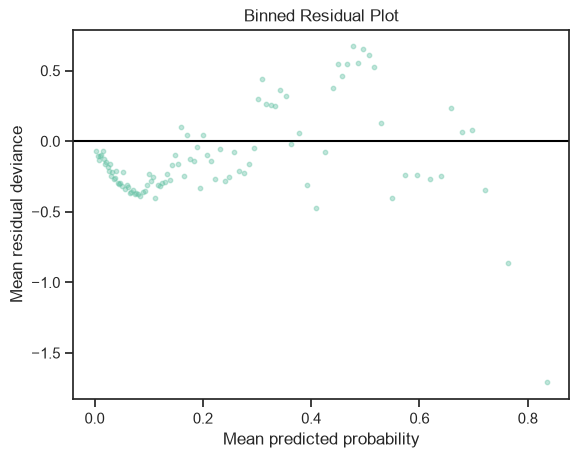

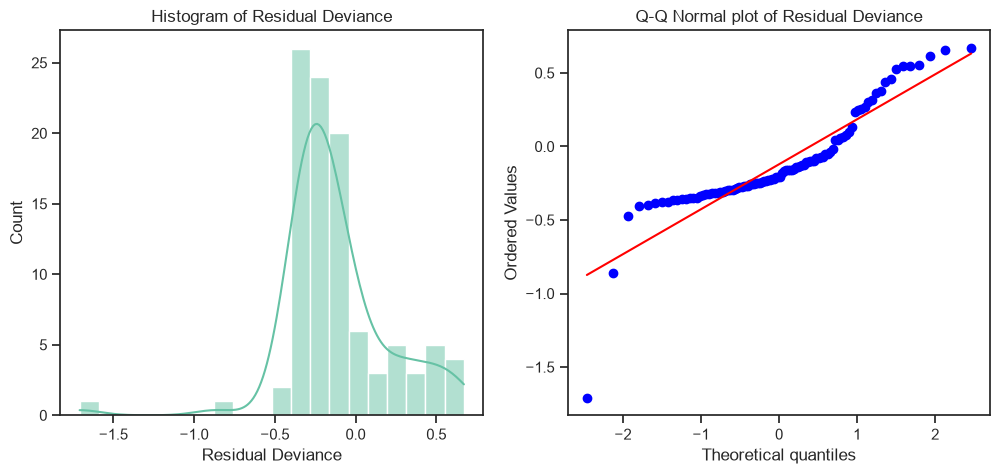

In [27]:
number_bins = 100

df = pd.DataFrame({
    'resid': hr_glm.resid_deviance,
    'yhat': hr_glm.predict()
})

df['bin'] = pd.qcut(df['yhat'], q=number_bins, duplicates='drop')

plot_df = df.groupby('bin').agg(
    mean_pred=('yhat', 'mean'),
    mean_resid=('resid', 'mean')
)

plt.scatter(plot_df['mean_pred'], plot_df['mean_resid'], s=10, alpha=0.4)
plt.axhline(0, color='black')
plt.xlabel("Mean predicted probability")
plt.ylabel("Mean residual deviance")
plt.title("Binned Residual Plot")
plt.show()

plot_resid_dist(plot_df['mean_resid'],
               xlab='Residual Deviance',
               title='Histogram of Residual Deviance')
#plot_resid_dist(df['resid'])

We can also apply bootstrap resampling to the model parameter estimates. Execute the code in the cell below to compute and display the bootstrap distribution of the model parameters.  

Parameter = satisfaction_level
Mean = -3.3598983771838453
Upper confidence interval = -3.0679589919648964
Lower confidence interval = -3.6880066869020682


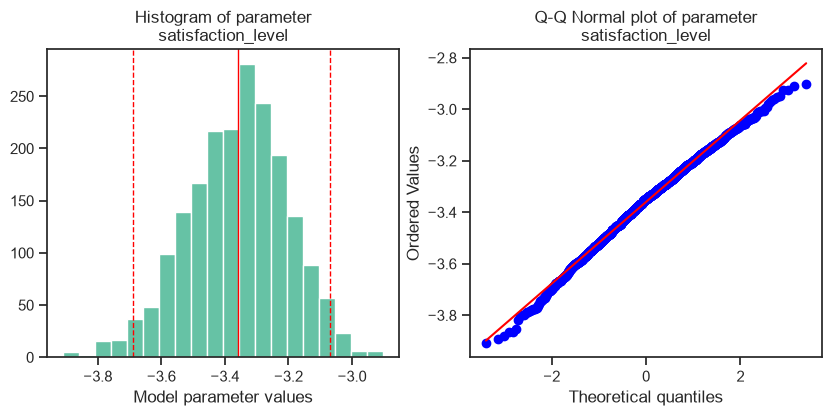

Parameter = average_montly_hours
Mean = 2.1445662111468495
Upper confidence interval = 2.4866557386716233
Lower confidence interval = 1.8493348260739915


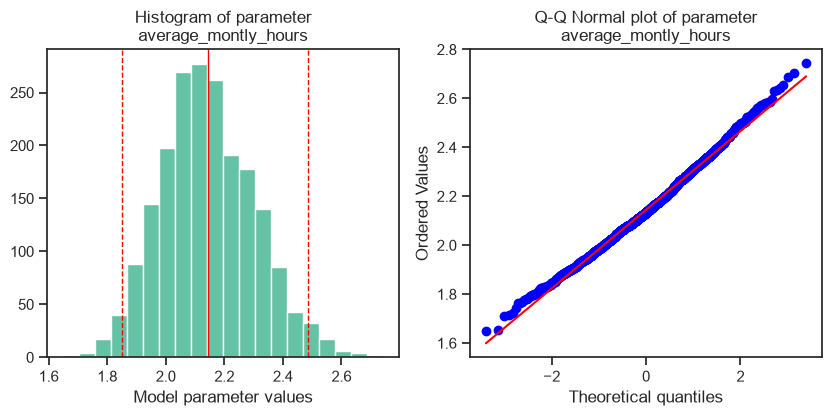

Parameter = last_evaluation
Mean = 1.6063190481398766
Upper confidence interval = 1.9395792067708142
Lower confidence interval = 1.309354773705031


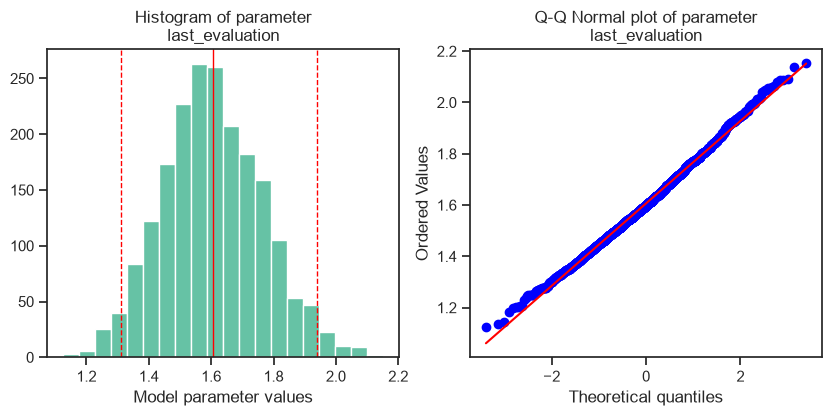

Parameter = salary
Mean = -2.063807379580938
Upper confidence interval = -1.5048797744102858
Lower confidence interval = -2.7955370564434157


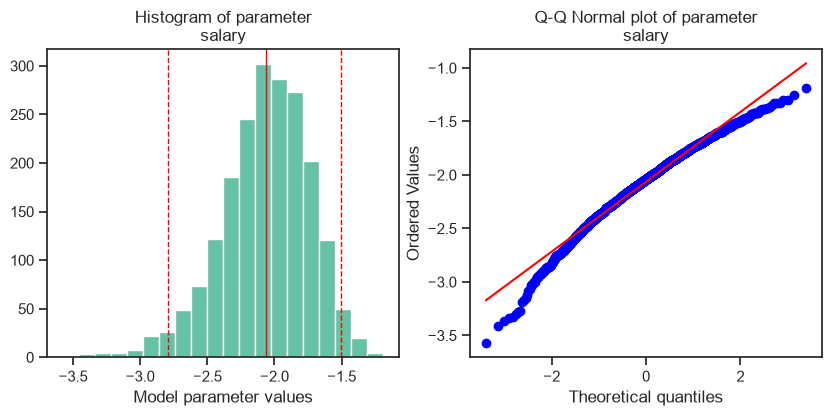

Parameter = promotion_last_5years
Mean = -1.0154567953206493
Upper confidence interval = -0.963995575589017
Lower confidence interval = -1.0709033201810185


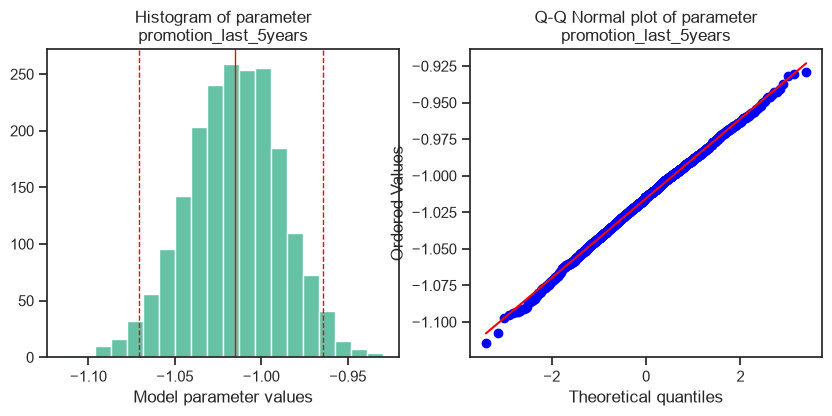

Parameter = number_project
Mean = 0.26943886949786416
Upper confidence interval = 0.3148348075929848
Lower confidence interval = 0.2247753089399082


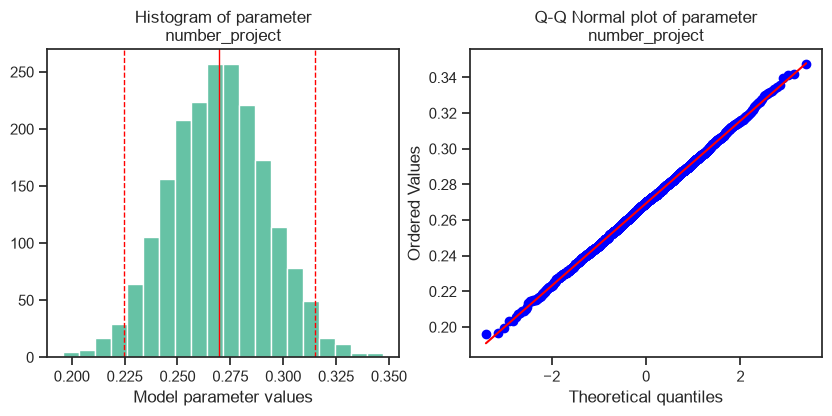

Parameter = time_spend_company
Mean = -0.44108945118753684
Upper confidence interval = -0.12824393179125332
Lower confidence interval = -0.7800127444908118


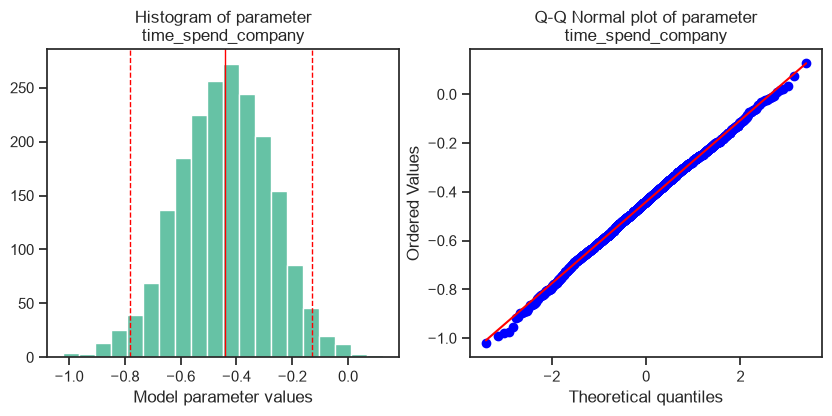

Parameter = salary:last_evaluation
Mean = 0.6032288389234441
Upper confidence interval = 0.9512938683998976
Lower confidence interval = 0.2771950248725622


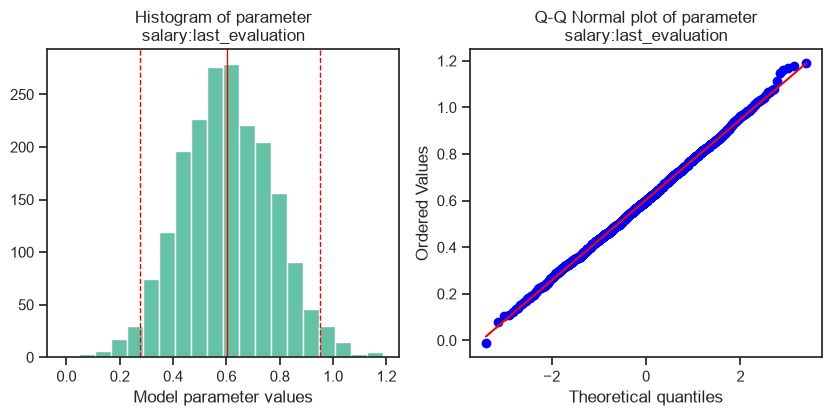

Parameter = promotion_last_5years:last_evaluation
Mean = 0.6308611227496886
Upper confidence interval = 0.9693550202239548
Lower confidence interval = 0.3024470524681696


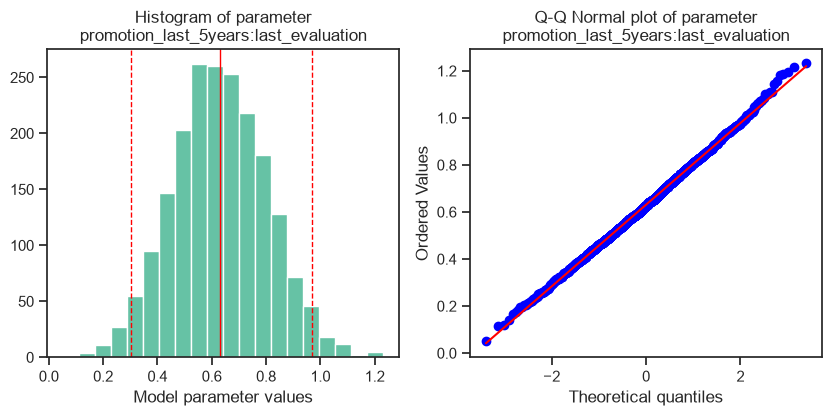

In [28]:
def resample_logistic_regression(df, n_boots, n_params=2, formula='y ~ x'):
    ## array to hold the bootstrap samples of the parameters
    boot_samples = np.zeros((n_boots,n_params))
    n_samples = df.shape[0]
    ## Loop over the number of resamples
    for i in range(n_boots):
        ## Create a bootstrap sample of the data frame
        boot_sample = df.sample(n=n_samples, replace=True)
        ## Compute the GLM model
        boot_model = smf.glm(formula=formula, 
                             data=boot_sample, 
                             family=sm.families.Binomial()).fit()
        ## Save the model parameters in the array
        boot_samples[i,:] = boot_model._results.params
    return boot_samples

logistic_param_boots = resample_logistic_regression(hr_data, 
                                                    2000, 
                                                    n_params=12, 
                                                    formula=formula)
for i,parameter in enumerate(['satisfaction_level',
                              'average_montly_hours',
                              'last_evaluation', 
                              'salary',
                              'promotion_last_5years',
                              'number_project',
                              'time_spend_company',
                              'salary:last_evaluation',
                              'promotion_last_5years:last_evaluation'
    ]):  
    plot_boot_params(logistic_param_boots[:,i], parameter=parameter)

> **Exercise 22-8:**
> 1. Examine the residual plots. How would you describe these residuals in terms of the ideal Normal distribution? What do they tell you about the fit of the model?
> 2. What does the bootstrap distributions, particularly the Q-Q normal plots, of the model parameters tell you about the uncertainty of the parameter estimates for this model?  

> **Answers:**
> 1.     
> 2.     

Along with the deviance, Pearson residuals can provide insight into model fit. Execute the code in the cell below to display the Pearson residuals of the model.           

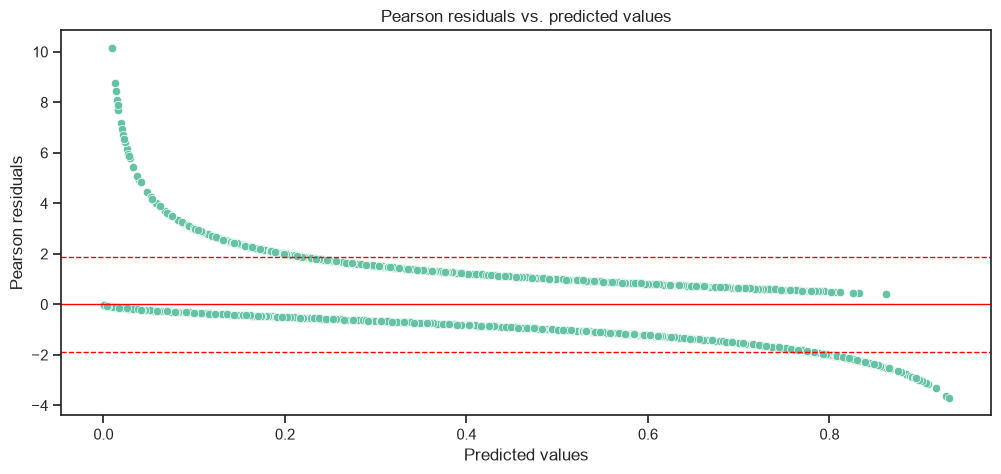

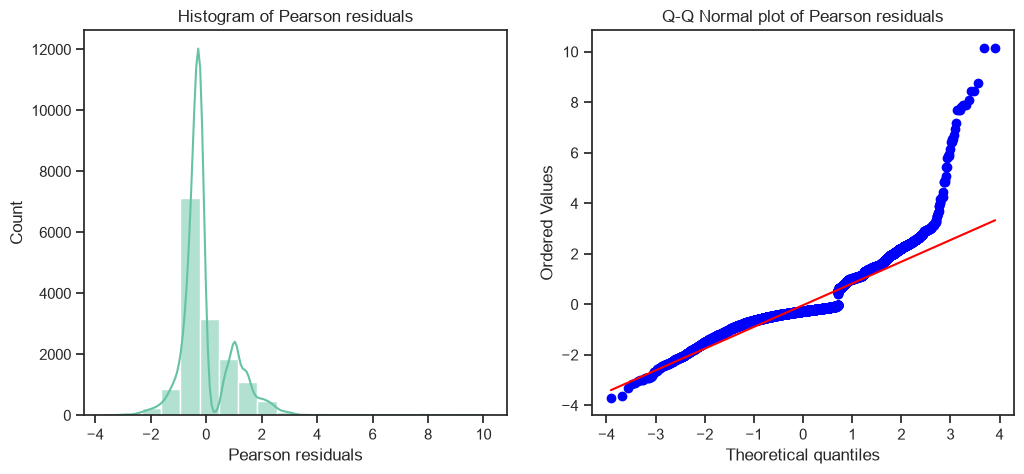

In [29]:
hr_data['pearson_resid'] = hr_glm.resid_pearson
hr_data['predicted'] = hr_glm.predict() # predict probabilities 
residual_plot(hr_data, 
              predicted='predicted', 
              resids='pearson_resid',
              ylab='Pearson residuals',
              title='Pearson residuals vs. predicted values')
plot_resid_dist(hr_data['pearson_resid'],
               xlab='Pearson residuals',
               title='Histogram of Pearson residuals')

> **Exercise 22-9:** Interpretation of Pearson residuals for a binomial model is not as straight forward as OLS regression. While ideally Pearson residuals are Normally distributed, the pattern vs. predicted values are along a pair of curves, one for each possible response. Significant breaks in slope or 'tails' om the curves indicate outliers. Do you see evidence of such outliers in these curves and the distribution of the Pearson residuals?

> **Answer:**     

It is likely we could improve the model by first investigating and then editing the outliers. We will to pursue improving the model fit any further here.  

### Marginal effects of independent variables    

Determining the effect of changing independent variables in an OLS model is quite straight forward as we have seen. However, this is not the case for nonlinear GLM models. For nonlinear models we must work with [**marginal effects**](https://library.virginia.edu/data/articles/a-beginners-guide-to-marginal-effects) on the probability. Marginal effects are computed by taking derivatives with respect to each of the variables. For the ith variable we can compute the marginal effect on the response $y$ as:   

$$P( marginal_i) = \frac{dy}{dx_i} = \frac{rate\ of\ change\ of\ response}{change\ of\ variable\ i}$$

When computing marginal effects we need to choose the point at which to measure. In other words, we need to choose the values of the independent variables at which we compute the derivative. The [Statsmodels `get_margeff`](https://www.statsmodels.org/devel/generated/statsmodels.discrete.discrete_model.LogitResults.get_margeff.html) offers several options for the `at` argument. Given that the model has interaction (nonlinear) terms we can only measure marginal effects at the mean of the independent variables or by specifying specific values of the variables. We will chose the former to simplify the process.    

> **Exercise 22-10:** Execute the code in the cell below to compute the marginal effects for this model. 

In [30]:
hr_glm.get_margeff(at='mean').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
         GLM Marginal Effects        
=====================================
Dep. Variable:                   left
Method:                          dydx
At:                              mean
=========================================================================================================
                                           dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
C(salary)[T.low]                          0.2855      0.018     16.248      0.000       0.251       0.320
C(salary)[T.medium]                       0.2132      0.018     11.891      0.000       0.178       0.248
C(promotion_last_5years)[T.1]            -0.2684      0.041     -6.512      0.000      -0.349      -0.188
satisfaction_level                       -0.1362      0.003    -40.971      0.000      -0.143      -0.130
average_montly_hours                      0.0361      0.003     10.335      0.000       0.029       0.043
last_evaluation                          -0.0577      0.018     -3.281      0.001      -0.092      -0.023
salary[T.low]:last_evaluation             0.0794      0.018      4.432      0.000       0.044       0.115
salary[T.medium]:last_evaluation          0.0830      0.018      4.597      0.000       0.048       0.118
number_project                           -0.0710      0.003    -20.562      0.000      -0.078      -0.064
time_spend_company                        0.0984      0.003     29.089      0.000       0.092       0.105
promotion_last_5years:last_evaluation    -0.0916      0.035     -2.597      0.009      -0.161      -0.022
=========================================================================================================
"""

> Examine these results and answer the following questions.
> 1. Why are the marginal effects measured in terms of changes in probability for a GLM model?
> 2. Why is it not possible to interpret the marginal effect with the `at=overall` options?
> 3. What statement can you make about how salary affects the probability that a person leaves the company?
> 4. If a person has had a promotion in the past 5 years are they more or less likely to leave the company with a longer time since the last evaluation and why?    

> **Answers:**
> 1.     
> 2.    
> 3.    
> 4.    

## GLM Example; Poisson Regression    

We will now apply a GLM to a Poisson regression example. Poisson regression is another example of a nonlinear response model. Along with some other distributions, Poisson regression is supported in many software packages, including [StatsModels Generalied Linear Models (GLM)](https://www.statsmodels.org/stable/glm.html) and Scikit-Learn [Generalized-linear-regression](https://scikit-learn.org/stable/modules/linear_model.html#generalized-linear-regression). Examination of this documentation shows a number of built in link functions and inverse link functions. Creating link functions for other distributions is supported as well.   

Recalling that the Poisson distribution has an exponential form with a single parameter, $\lambda$. The parameter, $\lambda$, is the expected arrival rate of the process. The predictions, $y$, given the observations, $x$ and the model parameter, $\lambda$, can then be written:      

$$log \big[ \mathtt{E}(y | x) \big] = x \lambda \Longleftrightarrow \mathtt{E}(y | x) = e^{x \lambda }$$

We can extend this relationship by using a linear model for $\lambda$, so that so that the expected arrival rate changes with the independent variables. For example, for a linear model with intercept, $\beta_0$, and $p$ dimensional slope parameter vector, $\vec{\beta}$. The Poisson regression estimate of $\lambda_i$, for a $p$ dimensional observation vector $\mathbf{x}_i $ is then:     

$$log(\lambda_i) = \beta_0 + \mathbf{x}_i \vec{\beta} \Longleftrightarrow \lambda_i = e^{(\beta_0 + \mathbf{x}_i $\vec{\beta})}$$

We can now use the above relations in the formulation of the Poisson distribution to find the link function ($e^{x_i \lambda_i }$) and inverse link function:   

\begin{align}
log \big[ \mathtt{E}(y_i |x_i) \big] = x_i \lambda_i &\Longleftrightarrow \mathtt{E}(y_ | x_i) = e^{x_i \lambda_i } \\
log \big[ \mathtt{E}(y_i |x_i) \big] = \beta_0 + \mathbf{x}_i \vec{\beta} &\Longleftrightarrow \mathtt{E}(y_ | x_i) = e^{\beta_0 + \mathbf{x}_i \vec{\beta} }
\end{align}

### Poisson regression example    

It is time to try and example. We will work with a dataset for the number (arrival in Poisson regression terms) of awards for high school students in three different academic programs. There are two independent variables, the program and the student's standardized math test score. These data are from the [UCLA Advanced Research Computing, Statistical Methods and Data Analytics](https://stats.oarc.ucla.edu/r/dae/poisson-regression/#:~:text=Examples%20of%20Poisson%20regression,the%20course%20of%2020%20years) group. Since the dependent variable is a count, number of awards, this problem is a candidate to try Poisson regression.     

Now, run th code in the cell below to load the dataset, prepare the values, and display the first few lines.   

In [31]:
program_codes = {1:'General', 2:'Academic', 3:'Vocational'}
award_scores = pd.read_csv("https://stats.idre.ucla.edu/stat/data/poisson_sim.csv")
award_scores['prog'] = award_scores['prog'].astype('object')
award_scores['prog'] = award_scores['prog'].replace(program_codes)
award_scores.head(10)

,id,num_awards,prog,math
0,45,0,Vocational,41
1,108,0,General,41
2,15,0,Vocational,44
3,67,0,Vocational,42
4,153,0,Vocational,40
5,51,0,General,42
6,164,0,Vocational,46
7,133,0,Vocational,40
8,2,0,Vocational,33
9,53,0,Vocational,46


Execute the code in the cell below to standardize the math scores.  

In [32]:
award_scores['math'] = (award_scores['math'] - award_scores['math'].mean()) / award_scores['math'].std()

To get a feel from these data, execute the code in the cell below to examine the courts of awards by program type.  

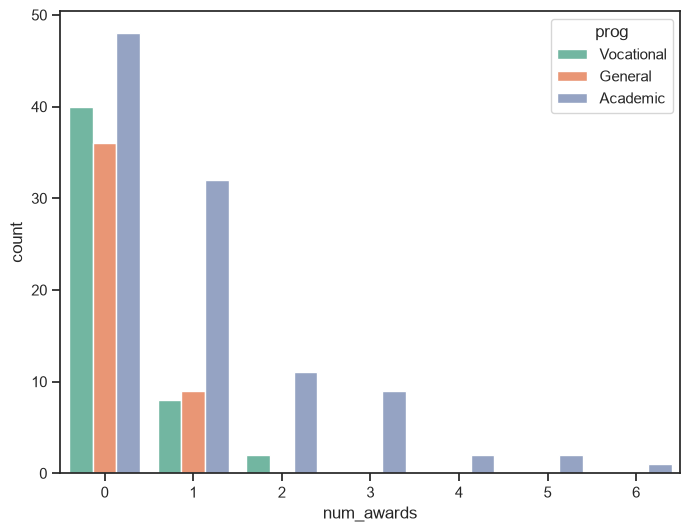

In [33]:
fig,ax = plt.subplots(figsize=(8,6))
sns.countplot(data=award_scores, x='num_awards',hue='prog', ax=ax);

As you can see, most students receive no awards, with a small number receiving up to 6.  

> **Exercise 22-11:** You will now construct and evaluate a Poisson regression model for these count data by these steps:    
> 1. Using [statsmodels.formula.api.poisson](https://www.statsmodels.org/dev/generated/statsmodels.formula.api.poisson.html) define and fit a model using the formula `'num_awards ~ math + C(prog)'`.   
> 2. Display the summary of the model.   

In [34]:
## Put your code below



Optimization terminated successfully.
         Current function value: 0.913761
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Poisson Regression Results                          
==============================================================================
Dep. Variable:             num_awards   No. Observations:                  200
Model:                        Poisson   Df Residuals:                      196
Method:                           MLE   Df Model:                            3
Date:                Sun, 20 Sep 2026   Pseudo R-squ.:                  0.2118
Time:                        09:11:29   Log-Likelihood:                -182.75
converged:                       True   LL-Null:                       -231.86
Covariance Type:            nonrobust   LLR p-value:                 3.747e-21
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.4701      0.138     -3.405      0.001      -0.741      -0.199
C(prog)[T.General]       -1.0839      0.358     -3.025      0.002      -1.786      -0.382
C(prog)[T.Vocational]    -0.7140      0.320     -2.231      0.026      -1.341      -0.087
math                      0.6572      0.099      6.619      0.000       0.463       0.852
=========================================================================================
"""

> Examine these results and answer these questions.      
> 1. Is the model over-fit and why?
> 2. Why can we not directly interpret these coefficients as effect sizes?     

> **Answer:**
> 1.    
> 2.     

> *Note:* For this problem interaction terms can be tried. The model formula . Experiments show that including interaction terms either do not improve the model or resulted in over-fitting.    

> Execute the code in the cell below to display a plot of the data and the fitted regression lines.   

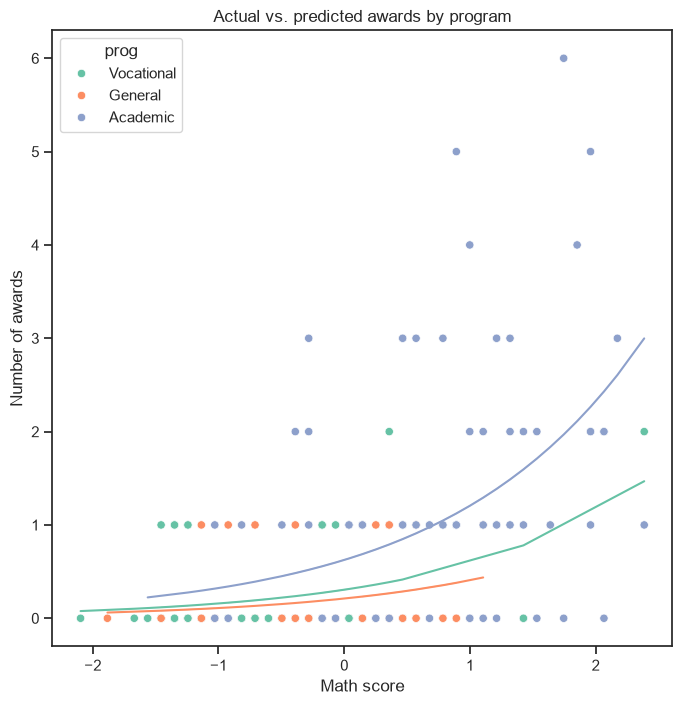

In [35]:
award_scores['predicted'] = poisson_glm.predict(award_scores)

fig,ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x='math', y='num_awards', hue='prog', data=award_scores, ax=ax);
sns.lineplot(x='math', y='predicted', hue='prog', data=award_scores, ax=ax, legend=False);
ax.set_title('Actual vs. predicted awards by program');
ax.set_xlabel('Math score');
ax.set_ylabel('Number of awards');
plt.show()

> This preliminary examination of the model fit looks promising.
>
> Next, let's investigate the Pearson residuals of this model. Execute the code in the cell below and examine the plots displayed.    

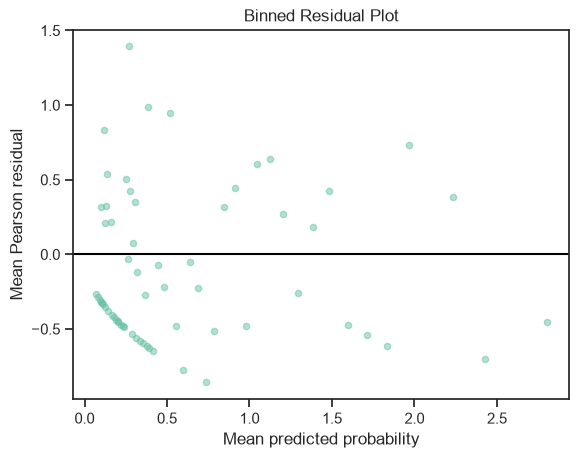

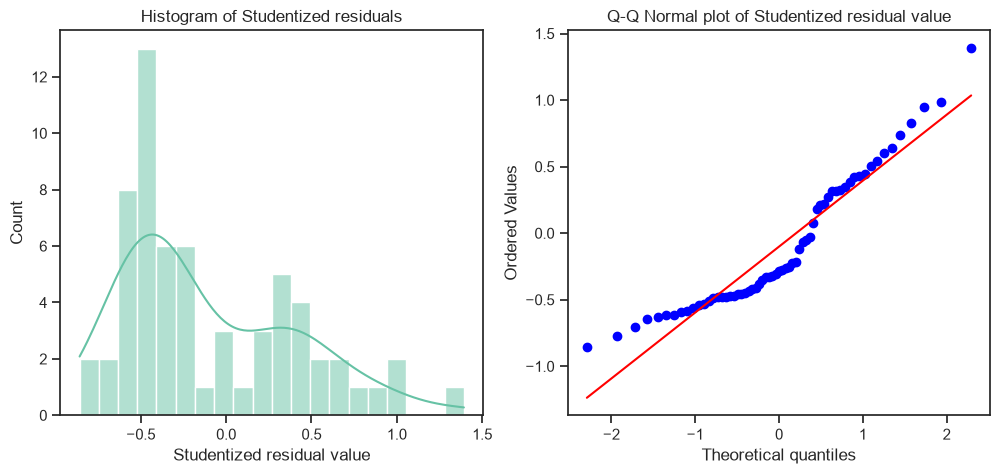

In [36]:
df = pd.DataFrame({
    'resid': poisson_glm.resid_pearson,
    'yhat': poisson_glm.predict()
})

df['bin'] = pd.qcut(df['yhat'], q=100, duplicates='drop')

plot_df = df.groupby('bin').agg(
    mean_pred=('yhat', 'mean'),
    mean_resid=('resid', 'mean')
)

plt.scatter(plot_df['mean_pred'], plot_df['mean_resid'], s=20, alpha=0.5)
plt.axhline(0, color='black')
plt.xlabel("Mean predicted probability")
plt.ylabel("Mean Pearson residual")
plt.title("Binned Residual Plot")
plt.show()

plot_resid_dist(plot_df['mean_resid'])

> The next question is how variable are the parameter estimates? To find out, execute the code in the cell below to find the bootstrap distributions of the model parameters.
>
> **Note:** If you see a convergence warning from the optimizer, run the code again. 

Parameter = Intercept
Mean = -0.4800392889712329
Upper confidence interval = -0.21384578909350238
Lower confidence interval = -0.7840450199646725


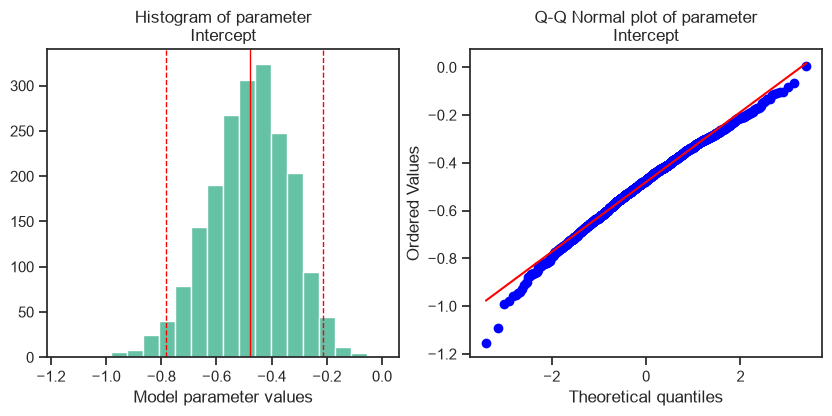

Parameter = General
Mean = -1.1273536194011773
Upper confidence interval = -0.5133372366454899
Lower confidence interval = -1.942436157017737


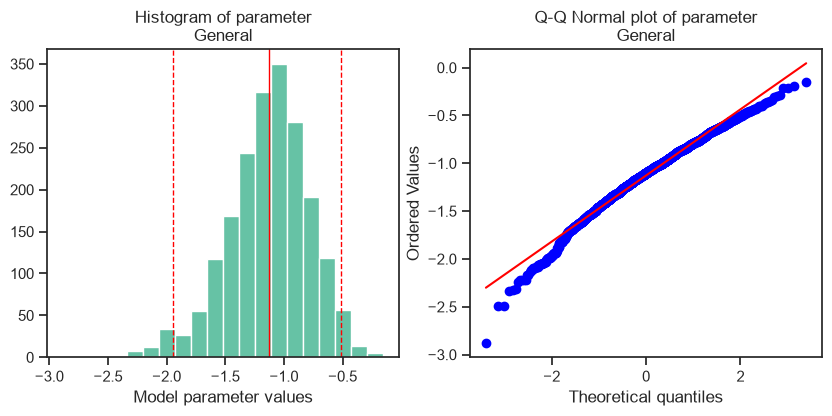

Parameter = Vocational
Mean = -0.7470900480431035
Upper confidence interval = -0.180047689087335
Lower confidence interval = -1.4794354620962509


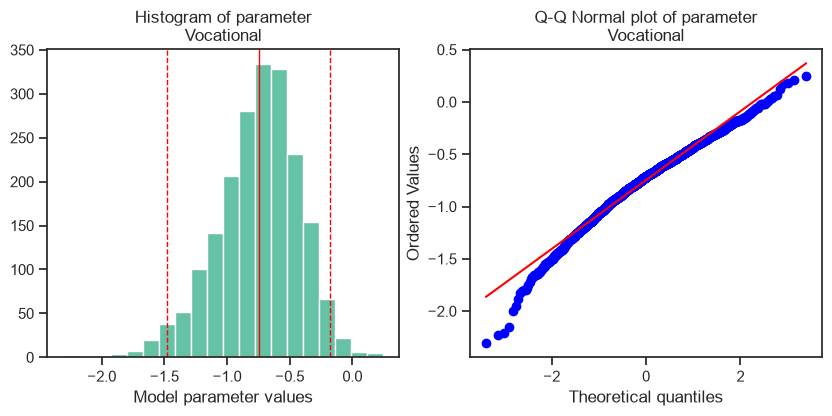

Parameter = Math
Mean = 0.6597355210498187
Upper confidence interval = 0.8726550467820159
Lower confidence interval = 0.45907907198678977


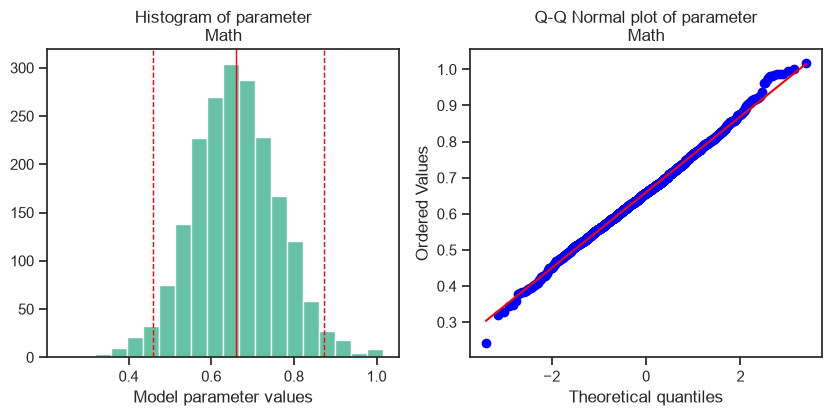

In [37]:
import contextlib
import io

def resample_regression_poisson(df, n_boots, n_params=2, formula='y ~ x', simulate=False):
    ## array to hold the bootstrap samples of the parameters
    boot_samples = np.zeros((n_boots,n_params))
    n_samples = df.shape[0]
    ## Loop over the number of resamples
    for i in range(n_boots):
        ## Create a bootstrap sample of the data frame
        boot_sample = df.sample(n=n_samples, replace=True)
        ## Compute the OLS model
        boot_model = smf.poisson(formula=formula, data=boot_sample).fit()
        ## Save the model parameters in the array
        boot_samples[i,:] = boot_model._results.params
        if simulate:
            df 
    return boot_samples


with contextlib.redirect_stdout(io.StringIO()):
    poisson_param_boots = resample_regression_poisson(award_scores, 2000, n_params=4, formula=formula)
for i,parameter in enumerate(['Intercept', 'General','Vocational', 'Math']):  
#for i,parameter in enumerate(['Intercept', 'math:C(prog)[T.General]','math:C(prog)[T.Vocational]', 'Math']): 
    plot_boot_params(poisson_param_boots[:,i], parameter=parameter)

> 5. Finally you can get a feel for the variability of the regression predictions by bootstrapping plotting the regression lines. Execute the code in the cell below and examine the results. The bootstrap resampling and display of the line plots with Seaborn will take some time.      

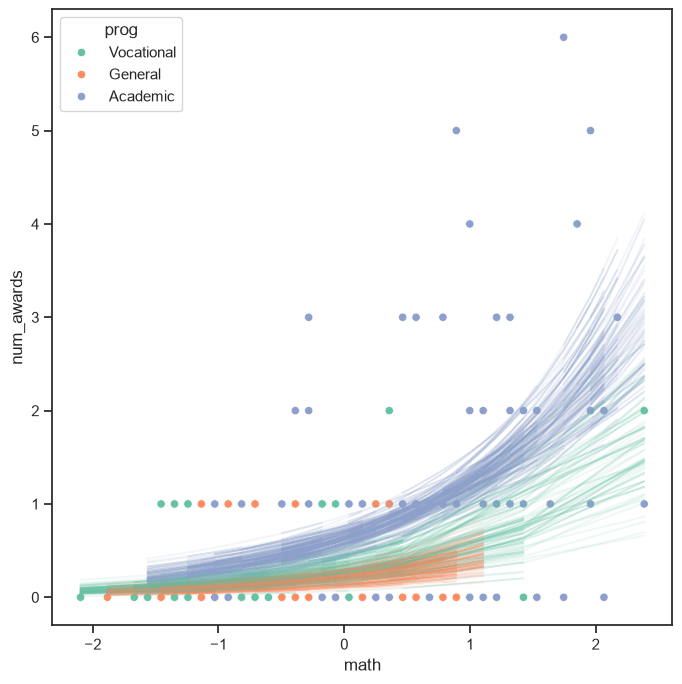

In [38]:
def resample_regression_poisson(df, formula,  ax, n_params=4, n_boots=100):
    ## array to hold the bootstrap samples of the parameters
    boot_samples = np.zeros((n_boots,n_params))
    n_samples = df.shape[0]
    ## Loop over the number of resamples
    for i in range(n_boots):
        ## Create a bootstrap sample of the data frame
        boot_sample = df.sample(n=n_samples, replace=True)
        boot_sample.index = range(len(boot_sample))

        ## Compute the OLS model
        boot_model = smf.poisson(formula=formula, data=boot_sample).fit()    
        boot_sample.loc[:,'predicted'] = boot_model.predict(boot_sample)
        sns.lineplot(x='math', y='predicted', hue='prog', hue_order=['Vocational','General', 'Academic'], data=boot_sample, ax=ax, alpha=0.1, legend=False);
        ## Save the model parameters in the array
        boot_samples[i,:] = boot_model._results.params
    return boot_samples

fig,ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x='math', y='num_awards', hue='prog', data=award_scores, ax=ax);
with contextlib.redirect_stdout(io.StringIO()):
    resample_regression_poisson(award_scores, formula,  ax)
plt.show()

> Examine the result and answer the following questions:     
> 3. Examine the distributions of the the model coefficients. How can you describe the distributions with respect to how close they are or not close to Normal?        
> 4. Next consider the bootstrap regression lines, keeping in mind that based on the regression model the value of the expected arrival rate parameter, $\lambda$ increases with the value of `math`, and that $\lambda$ is also the variance. How can you explain the increasing dispersion of the regression lines toward the right of the plot above?   
> 5. Given the dispersion of the regression lines, what are some reasonable inferences you can make and why?         

> **Answers:**    
> 3.    
> 4.    
> 5.    

Finally, execute the code in the cell below to compute and display the marginal effects for the Poisson model.   

In [39]:
poisson_glm.get_margeff(at='mean').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
       Poisson Marginal Effects      
=====================================
Dep. Variable:             num_awards
Method:                          dydx
At:                              mean
=========================================================================================
                           dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
C(prog)[T.General]       -0.4440      0.139     -3.205      0.001      -0.715      -0.173
C(prog)[T.Vocational]    -0.2925      0.127     -2.310      0.021      -0.541      -0.044
math                      0.2692      0.041      6.596      0.000       0.189       0.349
=========================================================================================
"""

> **Exercise 22-12:**
> 1. Consider the difference in the effect of a 10% improvement in math score. Is this change more or less than the effect of general vs. vocational program and why?   
> 2. Are these differences in effects statistically significance and why?   

> **Answers:**
> 1.    
> 2.    

## Regression With Ordinal Response   

Ordinal regression is another form of nonlinear response model. One often encounters ordinal variables, such as star ratings. These responses do not have a numeric value, but rather have a rank. For a variables with $n$ ordered ranks, $R \in [r_1, r_2,...,r_n]$, we can express the response:   
$$R= r_1 \prec r_2 \prec... \prec r_n$$

A model for ranked or ordinal response is constructed by a series of pairwise probit or logit nonlinear responses. The model finds the most probable repose from the pairwise ordering. This construction is not a GLM as there is no overall distribution assumption.  

### Generating an ordinal dataset     

Wine quality can be ranked, $low \prec medium \prec high$. The code in the cell below generates a synthetic ordinal dataset. Execute this code and examine the result.    

In [40]:
# Setting a random seed so results are reproducible
np.random.seed(42)
n_samples = 500

# Create realistic continuous features
alcohol = np.random.normal(10.5, 1.2, n_samples)
volatile_acidity = np.random.normal(0.5, 0.15, n_samples)
sulphates = np.random.normal(0.6, 0.1, n_samples)

# Generate a latent score to determine the ordinal wine quality tier
latent_score = 0.8 * alcohol - 2.5 * volatile_acidity + 1.5 * sulphates + np.random.normal(0, 1, n_samples)

# Map the latent score into discrete quality tiers (Low < Medium < High)
quality = pd.cut(latent_score, bins=[-np.inf, 6, 8, np.inf], labels=['Low', 'Medium', 'High'])

# Construct the local DataFrame
wine_df = pd.DataFrame({
    'alcohol': alcohol,
    'volatile_acidity': volatile_acidity,
    'sulphates': sulphates,
    'quality': quality
})

wine_df['quality'] = pd.Categorical(wine_df['quality'], categories=['Low', 'Medium', 'High'], ordered=True)
X = wine_df[['alcohol', 'volatile_acidity', 'sulphates']]
y = wine_df['quality']

print(wine_df.columns)
print('Unique values of quality ' + str(wine_df['quality'].unique()))
wine_df.head()

Index(['alcohol', 'volatile_acidity', 'sulphates', 'quality'], dtype='str')
Unique values of quality ['High', 'Medium', 'Low']
Categories (3, str): ['Low' < 'Medium' < 'High']


,alcohol,volatile_acidity,sulphates,quality
0,11.096057,0.638927,0.739936,High
1,10.334083,0.786412,0.692463,Medium
2,11.277226,0.290215,0.605963,High
3,12.327636,0.584445,0.535306,High
4,10.219016,0.402404,0.669822,High


### Constructing a model of ordinal data      

We will use the [OrderedModel from StatsModels](https://www.statsmodels.org/stable/generated/statsmodels.miscmodels.ordinal_model.OrderedModel.html) to construct an ordinal regression model for wine quality. Execute the code in the cell below and examine the results.  

In [41]:
formula = "quality ~ alcohol + volatile_acidity + sulphates + 1"

model = OrderedModel.from_formula(
    formula=formula, 
    data=wine_df, 
    distr='probit' # Can be 'probit' or 'logit'
)
res = model.fit(method='bfgs', disp=False) 
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                quality   Log-Likelihood:                -311.63
Model:                   OrderedModel   AIC:                             633.3
Method:            Maximum Likelihood   BIC:                             654.3
Date:                Sun, 20 Sep 2026                                         
Time:                        09:15:18                                         
No. Observations:                 500                                         
Df Residuals:                     495                                         
Df Model:                           3                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
alcohol              0.9075      0.068     13.319      0.000       0.774       1.041
volatile_acidity    -2.7146      0.428     -6.336      0.000      -3.554      -1.875
sulphates            0.4752      0.597      0.796      0.426      -0.695       1.645
Low/Medium           6.2871      0.775      8.116      0.000       4.769       7.805
Medium/High          0.7189      0.064     11.252      0.000       0.594       0.844
====================================================================================
"""

This model is over-fit. Some experimentation shows that the sulphates variable needs to be dropped. No interaction terms improved the model fit. Now execute the code in the cell below to fit another model.   

In [42]:
formula = "quality ~ alcohol + volatile_acidity + 1"

model = OrderedModel.from_formula(
    formula=formula, 
    data=wine_df, 
    distr='probit' # Can be 'probit' or 'logit'
)
res = model.fit(method='bfgs', disp=False) 
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                quality   Log-Likelihood:                -311.95
Model:                   OrderedModel   AIC:                             631.9
Method:            Maximum Likelihood   BIC:                             648.8
Date:                Sun, 20 Sep 2026                                         
Time:                        09:15:18                                         
No. Observations:                 500                                         
Df Residuals:                     496                                         
Df Model:                           2                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
alcohol              0.9045      0.068     13.304      0.000       0.771       1.038
volatile_acidity    -2.6919      0.427     -6.302      0.000      -3.529      -1.855
Low/Medium           5.9791      0.669      8.939      0.000       4.668       7.290
Medium/High          0.7184      0.064     11.245      0.000       0.593       0.844
====================================================================================
"""

> **Exercise 22-13:** This model is not over-fit. How can you explain the presence of two intercept terms? 

> **Answer:**      

Given that this example uses synthetic data, we will not put a lot of effort into examining residuals and parameter fit. We will create a plot of residual probability vs. fitting values. You can display this chart by executing the code in the cell below.  

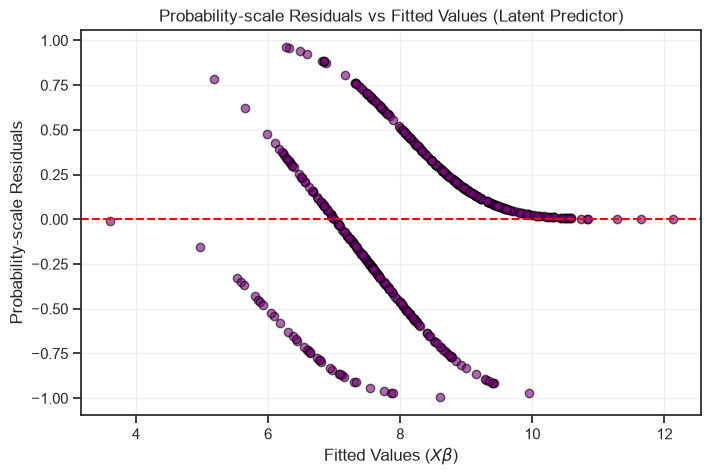

In [43]:
# Extract the probability-scale residuals
residuals = res.resid_prob

# Generate a proxy for "fitted values" 
# For ordinal models, the latent linear predictor (X * beta) serves as the fitted value
fitted_values = res.model.exog @ res.params[:res.model.exog.shape[1]]

# Create the Residual vs. Fitted plot
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals, alpha=0.6, color='purple', edgecolors='k')

# Add a horizontal reference line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.title('Probability-scale Residuals vs Fitted Values (Latent Predictor)')
plt.xlabel('Fitted Values ($X\\beta$)')
plt.ylabel('Probability-scale Residuals')
plt.grid(True, alpha=0.3)
plt.show()

This plot requires some explanation. Notice how the points line up on three curves. These curves represent the probabilities of low, medium and high wine quality. Notice how the range of fitted values overlap for the three curves, with the deviations for probability of classification. There are a few noticeable outliers that stand off away from the curves.   

Finally, let's examine the marginal effects for the the wine quality model. The StatsModels package does not contain a method to find the marginal effects of the ordinal regression model. But, with the help of Gemini we can construct our own code. Execute this code.       

In [45]:
# Set h and find a baseline prediction
h = 1e-5
original_probs = res.predict() 
marginal_effects_dict = {}

# Loop through the feature list
for col in ['alcohol','volatile_acidity']:
    X_perturbed = X.copy()
    X_perturbed[col] += h
    
    # Predict using the perturbed data
    probs_perturbed = res.predict(exog=X_perturbed)
    
    # Directly calculate on numpy arrays
    me_avg = ((probs_perturbed - original_probs) / h).mean(axis=0)
    marginal_effects_dict[col] = me_avg

# Build the DataFrame first using standard indexing
ame_df = pd.DataFrame.from_dict(marginal_effects_dict, orient='index')

# Explicitly map the wine categories over the columns
ame_df.columns = wine_df['quality'].cat.categories
ame_df['column sum'] = ame_df.sum(axis=1) # verify the effects sum to 0

print(ame_df.round(4))

                     Low  Medium    High  column sum
alcohol          -0.0876 -0.1468  0.2344        -0.0
volatile_acidity  0.2608  0.4369 -0.6977         0.0


> **Exercise 22-14:** Examine these results, noticing that the effects for each variable must sum to zero. Answer these questions.    
> 1. How does changing the level of alcohol affect the response?      
> 2. How does changing the level of volatile acid change the response? 

> **Answers:**
> 1.    
> 2.     

#### Copyright 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2026, Stephen F Elston. All rights reserved. 